# 双策略 × 多标的回测


## 1. 环境准备


In [1]:
import sys, os
import pandas as pd
import numpy as np
import tushare as ts
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# 项目根（notebook 位于 result/ 下，向上跳两级）
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'backtest', '__init__.py')):
    for up in [os.getcwd(), os.path.dirname(os.getcwd())]:
        candidate = up if os.path.exists(os.path.join(up, 'backtest', '__init__.py')) else os.path.dirname(up)
        if os.path.exists(os.path.join(candidate, 'backtest', '__init__.py')):
            PROJECT_ROOT = candidate
            break
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from backtest.engine import BacktestEngine
from backtest.evaluator import Evaluator
from backtest.visualizer import Visualizer

# 环境常量
DATA_CACHE_DIR = os.path.join(PROJECT_ROOT, 'data')
CYPOWER_CSV = os.path.join(PROJECT_ROOT, 'cypower_daily_till_20260628.csv')
BACKEND_ENV = os.path.join(PROJECT_ROOT, 'stock-web-tool', 'backend', '.env')
CHARTS_DIR = os.path.join(PROJECT_ROOT, 'result', 'backtest_charts')

# 加载 Tushare Token
load_dotenv(BACKEND_ENV)
TUSHARE_TOKEN = os.getenv('TUSHARE_TOKEN')
if not TUSHARE_TOKEN:
    raise ValueError('未找到 TUSHARE_TOKEN，请检查 backend/.env')
ts.set_token(TUSHARE_TOKEN)
pro = ts.pro_api()

# 时间窗口
START_DATE, END_DATE = '20250630', '20260628'
START_DT, END_DT = pd.Timestamp('2025-06-30'), pd.Timestamp('2026-06-28')

# 标的清单
STOCKS_CONFIG = [
    ('长江电力', '600900.SH', 'local'),
    ('中芯国际', '688981.SH', 'tushare'),
    ('中际旭创', '300308.SZ', 'tushare'),
    ('紫金矿业', '601899.SH', 'tushare'),
]

print(f'项目根: {PROJECT_ROOT}')
print(f'数据缓存目录: {DATA_CACHE_DIR}')
print(f'回测窗口: {START_DATE} ~ {END_DATE}')
print(f'Token 已加载: {TUSHARE_TOKEN[:6]}...')


/Users/stella/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


项目根: /Users/stella/Documents/LLM辅助量化交易
数据缓存目录: /Users/stella/Documents/LLM辅助量化交易/data
回测窗口: 20250630 ~ 20260628
Token 已加载: aaf703...


## 2. 数据获取与 CSV 缓存


In [2]:
# 数据加载函数：优先级 本地CSV > 本地缓存CSV > tushare远程+写缓存
# 输出统一列：trade_date, open, high, low, close, adj_factor,
#             high_qfq, low_qfq, close_qfq

def load_stock_data(name, ts_code, source, local_csv=None):
    # 1) 本地 CSV（仅长江电力使用）
    if local_csv and os.path.exists(local_csv):
        df = pd.read_csv(local_csv)
        df['trade_date'] = pd.to_datetime(df['trade_date'])
        df = df.sort_values('trade_date').reset_index(drop=True)
        latest_adj = df['adj_factor'].iloc[-1]
        if 'high_qfq' not in df.columns:
            df['high_qfq'] = df['high'] * df['adj_factor'] / latest_adj
        if 'low_qfq' not in df.columns:
            df['low_qfq'] = df['low'] * df['adj_factor'] / latest_adj
        df = df[(df['trade_date'] >= START_DT) & (df['trade_date'] <= END_DT)].copy()
        df = df.reset_index(drop=True)
        print(f'[{name}] 来源=本地CSV  行数={len(df)}  '
              f'{df.trade_date.iloc[0].date()} ~ {df.trade_date.iloc[-1].date()}')
        return df

    # 2) 缓存 CSV
    cache_path = os.path.join(DATA_CACHE_DIR,
                              f'{ts_code}_daily_{START_DATE}_{END_DATE}.csv')
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=['trade_date'])
        df = df.sort_values('trade_date').reset_index(drop=True)
        print(f'[{name}] 来源=本地缓存  行数={len(df)}  '
              f'{df.trade_date.iloc[0].date()} ~ {df.trade_date.iloc[-1].date()}')
        return df

    # 3) tushare 远程拉取（含重试）
    print(f'[{name}] 来源=tushare远程拉取 ...')
    daily_df = None
    for attempt in range(3):
        try:
            daily_df = pro.daily(ts_code=ts_code,
                                 start_date=START_DATE, end_date=END_DATE)
            break
        except Exception as e:
            msg = str(e)
            if '40203' in msg:
                raise RuntimeError(
                    f'tushare daily 接口权限未开通(40203): {ts_code}')
            if '频率' in msg and attempt < 2:
                print('  频率限制，5秒后重试...')
                import time; time.sleep(5)
                continue
            raise
    if daily_df is None or daily_df.empty:
        raise ValueError(f'未获取到 {ts_code} 的日线数据')
    daily_df = daily_df.sort_values('trade_date').reset_index(drop=True)
    daily_df['trade_date'] = pd.to_datetime(daily_df['trade_date'])

    # 复权因子（带降级）
    try:
        adj_df = pro.adj_factor(ts_code=ts_code,
                                start_date=START_DATE, end_date=END_DATE)
    except Exception as e:
        print(f'  [WARN] adj_factor 获取失败: {e}，降级为原始价')
        adj_df = None
    if adj_df is not None and not adj_df.empty:
        adj_df['trade_date'] = pd.to_datetime(adj_df['trade_date'])
        adj_df = adj_df[['trade_date', 'adj_factor']].sort_values('trade_date')
        daily_df = daily_df.merge(adj_df, on='trade_date', how='left')
        daily_df['adj_factor'] = daily_df['adj_factor'].ffill().bfill()
    else:
        daily_df['adj_factor'] = 1.0

    # 前复权列
    latest_adj = daily_df['adj_factor'].iloc[-1]
    factor = daily_df['adj_factor'] / latest_adj
    for col in ['high', 'low', 'close']:
        daily_df[f'{col}_qfq'] = (daily_df[col] * factor).round(4)

    # 窗口截取 + 落盘缓存
    daily_df = daily_df[(daily_df['trade_date'] >= START_DT) &
                        (daily_df['trade_date'] <= END_DT)].copy()
    daily_df = daily_df.sort_values('trade_date').reset_index(drop=True)
    os.makedirs(DATA_CACHE_DIR, exist_ok=True)
    out_cols = ['trade_date', 'open', 'high', 'low', 'close',
                'adj_factor', 'high_qfq', 'low_qfq', 'close_qfq']
    daily_df[out_cols].to_csv(cache_path, index=False)
    print(f'[{name}] 缓存已写入: {cache_path}  行数={len(daily_df)}  '
          f'{daily_df.trade_date.iloc[0].date()} ~ {daily_df.trade_date.iloc[-1].date()}')
    return daily_df


# 批量加载
STOCKS = {}
for name, code, source in STOCKS_CONFIG:
    local_csv = CYPOWER_CSV if source == 'local' else None
    STOCKS[name] = load_stock_data(name, code, source, local_csv=local_csv)

# 窗口对齐核对
print('\n=== 窗口对齐核对 ===')
for name, df in STOCKS.items():
    print(f'{name:>6}  {df.trade_date.iloc[0].date()} ~ {df.trade_date.iloc[-1].date()}  '
          f'共 {len(df)} 个交易日')

# 引擎硬依赖的列检查
required_cols = {'trade_date', 'open', 'close_qfq'}
for name, df in STOCKS.items():
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'{name} 缺少字段: {missing}')
print('所有标的字段校验通过。')


[长江电力] 来源=本地CSV  行数=241  2025-06-30 ~ 2026-06-26
[中芯国际] 来源=本地缓存  行数=235  2025-06-30 ~ 2026-06-26
[中际旭创] 来源=本地缓存  行数=241  2025-06-30 ~ 2026-06-26
[紫金矿业] 来源=本地缓存  行数=241  2025-06-30 ~ 2026-06-26

=== 窗口对齐核对 ===
  长江电力  2025-06-30 ~ 2026-06-26  共 241 个交易日
  中芯国际  2025-06-30 ~ 2026-06-26  共 235 个交易日
  中际旭创  2025-06-30 ~ 2026-06-26  共 241 个交易日
  紫金矿业  2025-06-30 ~ 2026-06-26  共 241 个交易日
所有标的字段校验通过。


## 3. 策略参数（集中配置，独立于函数）


In [3]:
# 双均线策略
MA_PARAMS = {'fast': 5, 'slow': 20}

# 海龟策略（唐奇安突破 + ATR 止损）
TURTLE_PARAMS = {
    'entry_period': 20,     # N：唐奇安入场通道（前 N 日最高）
    'exit_period': 10,      # M：唐奇安出场通道（前 M 日最低）
    'atr_period': 14,       # ATR 窗口
    'atr_multiplier': 2.0,  # k：ATR 止损倍数
}

print('MA_PARAMS    =', MA_PARAMS)
print('TURTLE_PARAMS =', TURTLE_PARAMS)


MA_PARAMS    = {'fast': 5, 'slow': 20}
TURTLE_PARAMS = {'entry_period': 20, 'exit_period': 10, 'atr_period': 14, 'atr_multiplier': 2.0}


## 4. 信号函数


In [4]:
def dual_ma_signal(data, params):
    # 双均线交叉：MA(fast) > MA(slow) 满仓，否则空仓
    fast_ma = data['close_qfq'].rolling(params['fast']).mean()
    slow_ma = data['close_qfq'].rolling(params['slow']).mean()
    signals = pd.Series(0.0, index=data.index)
    signals[fast_ma > slow_ma] = 1.0
    return signals


def turtle_signal(data, params):
    # 海龟（唐奇安突破 + ATR 止损，有状态，仓位 0/1）
    # 空仓：close > 前 N 日 high_qfq 最高 -> 满仓，记录入场价
    # 持仓：close < 前 M 日 low_qfq 最低 或 close < 入场价 - k*ATR -> 清仓
    n, m = params['entry_period'], params['exit_period']
    k, atr_p = params['atr_multiplier'], params['atr_period']

    c = data['close_qfq'].values
    h = data['high_qfq'].values
    l = data['low_qfq'].values
    length = len(data)

    # True Range 与 ATR
    prev_c = np.concatenate([[np.nan], c[:-1]])
    tr = np.maximum(np.maximum(h - l, np.abs(h - prev_c)),
                    np.abs(l - prev_c))
    atr = pd.Series(tr).rolling(atr_p).mean().values

    # 唐奇安通道（均 shift(1)，避免未来函数）
    entry_high = pd.Series(h).rolling(n).max().shift(1).values
    exit_low = pd.Series(l).rolling(m).min().shift(1).values

    signals = np.zeros(length, dtype=float)
    position = 0.0
    entry_price = np.nan

    for t in range(length):
        if position == 0.0:
            if not np.isnan(entry_high[t]) and c[t] > entry_high[t]:
                position = 1.0
                entry_price = c[t]
        else:
            stop_price = entry_price - k * (atr[t] if not np.isnan(atr[t]) else 0)
            if (not np.isnan(exit_low[t]) and c[t] < exit_low[t]) or c[t] < stop_price:
                position = 0.0
                entry_price = np.nan
        signals[t] = position
    return pd.Series(signals, index=data.index)


# 策略集合
STRATEGIES = {
    '双均线': (dual_ma_signal, MA_PARAMS),
    '海龟':   (turtle_signal,  TURTLE_PARAMS),
}
print('已注册策略:', list(STRATEGIES.keys()))


已注册策略: ['双均线', '海龟']


## 5. 回测执行（2 策略 × 4 标的 = 8 组）


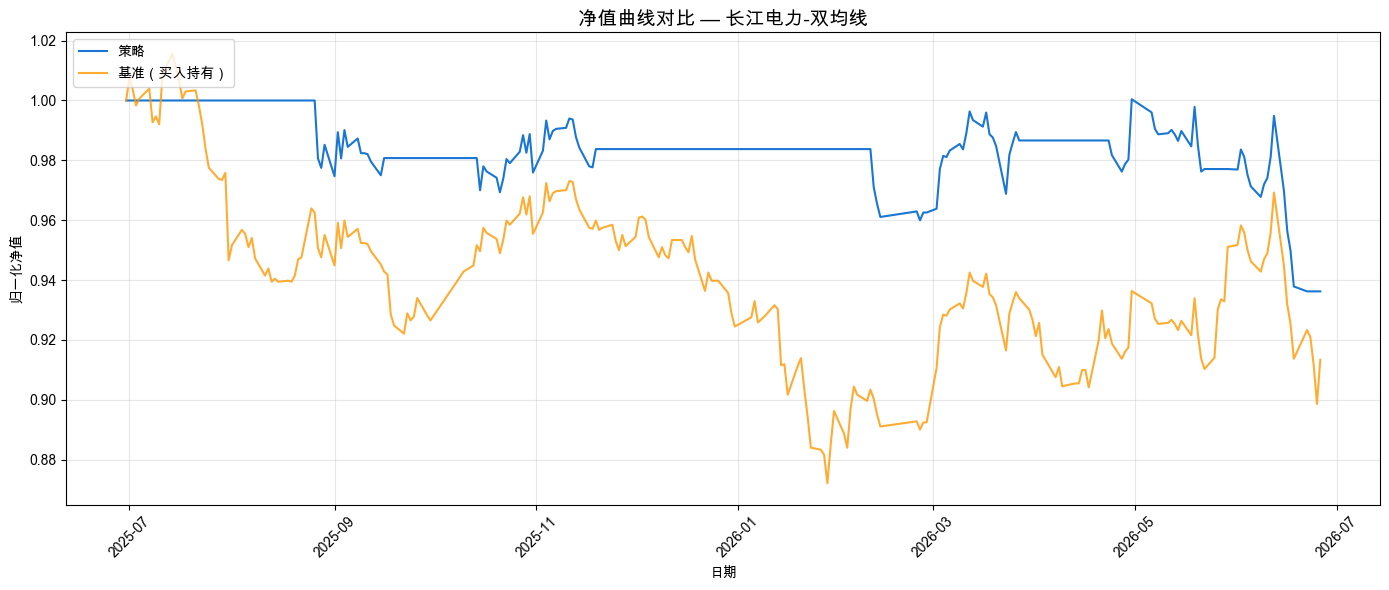

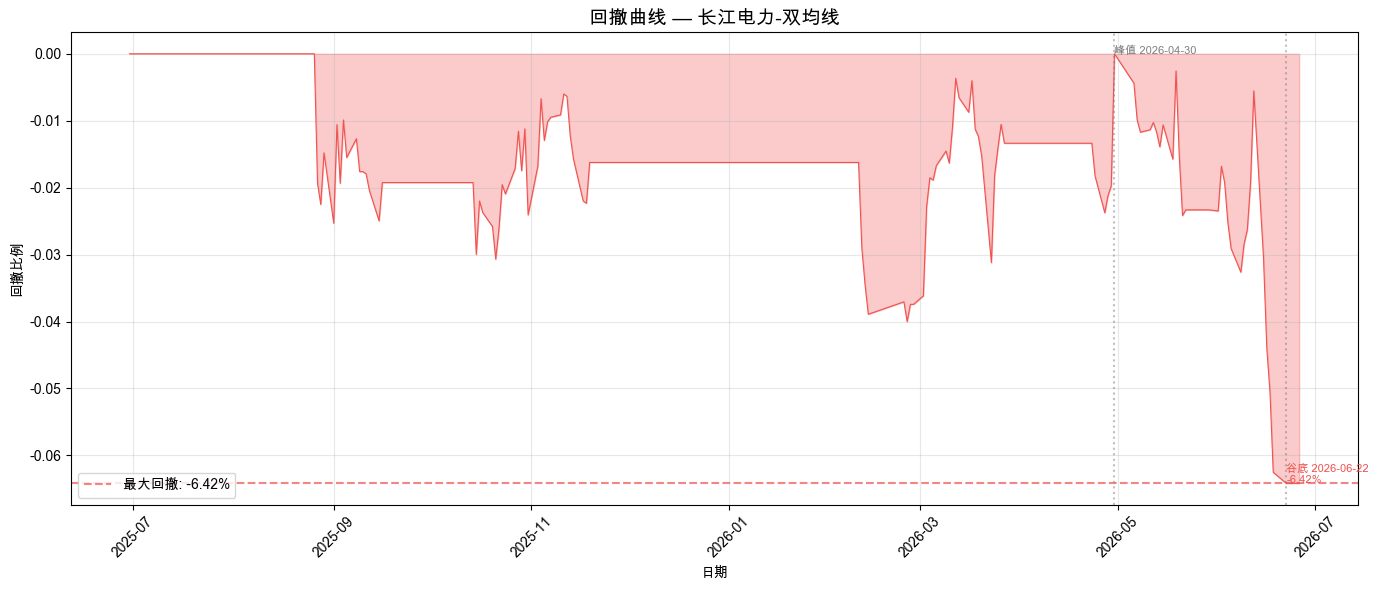

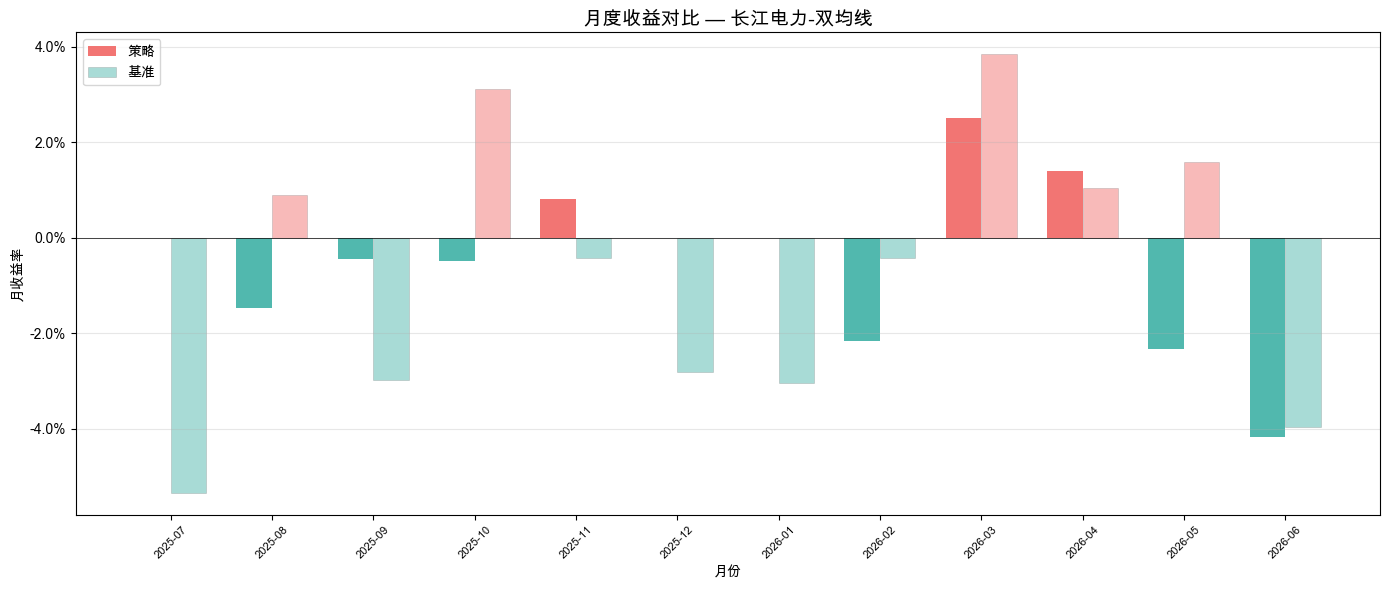

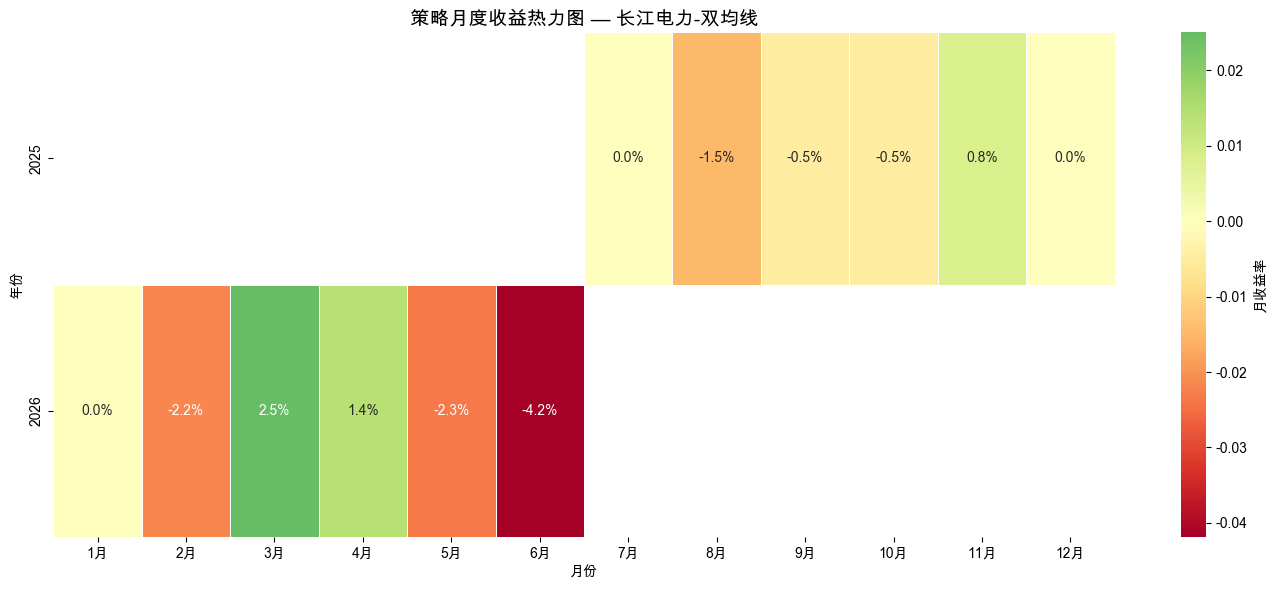

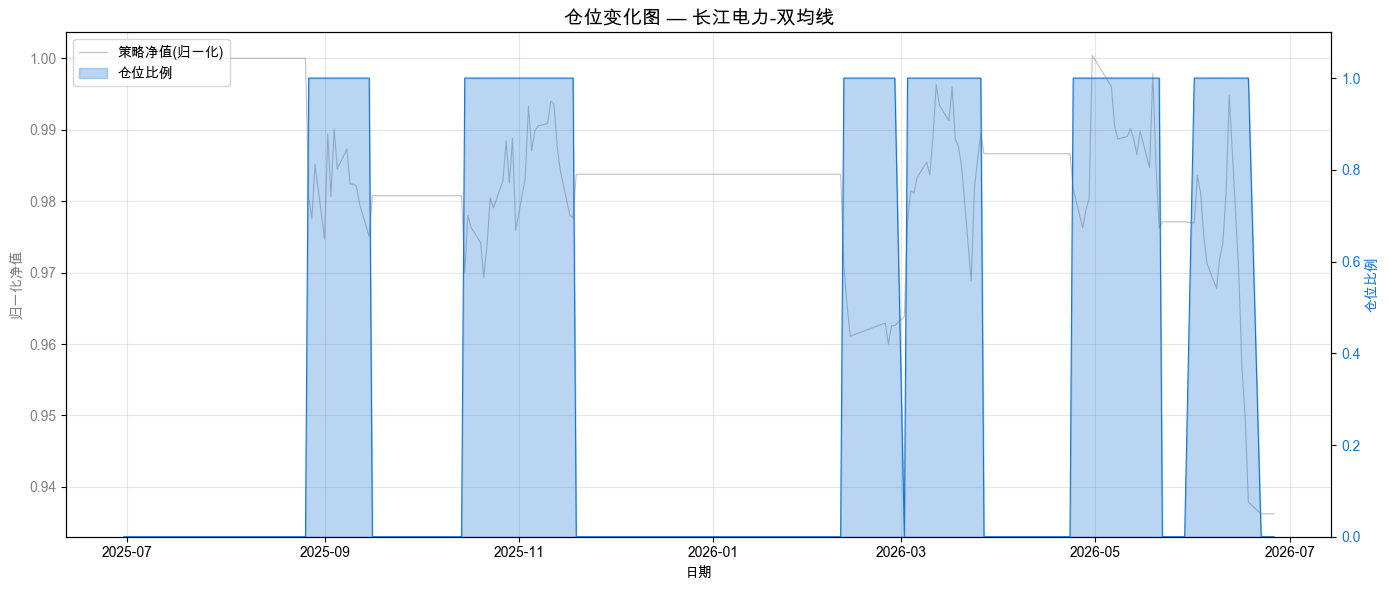

[OK] 长江电力-双均线: 累计=-6.38%  Sharpe=-1.130  MDD=-6.42%  交易=6次


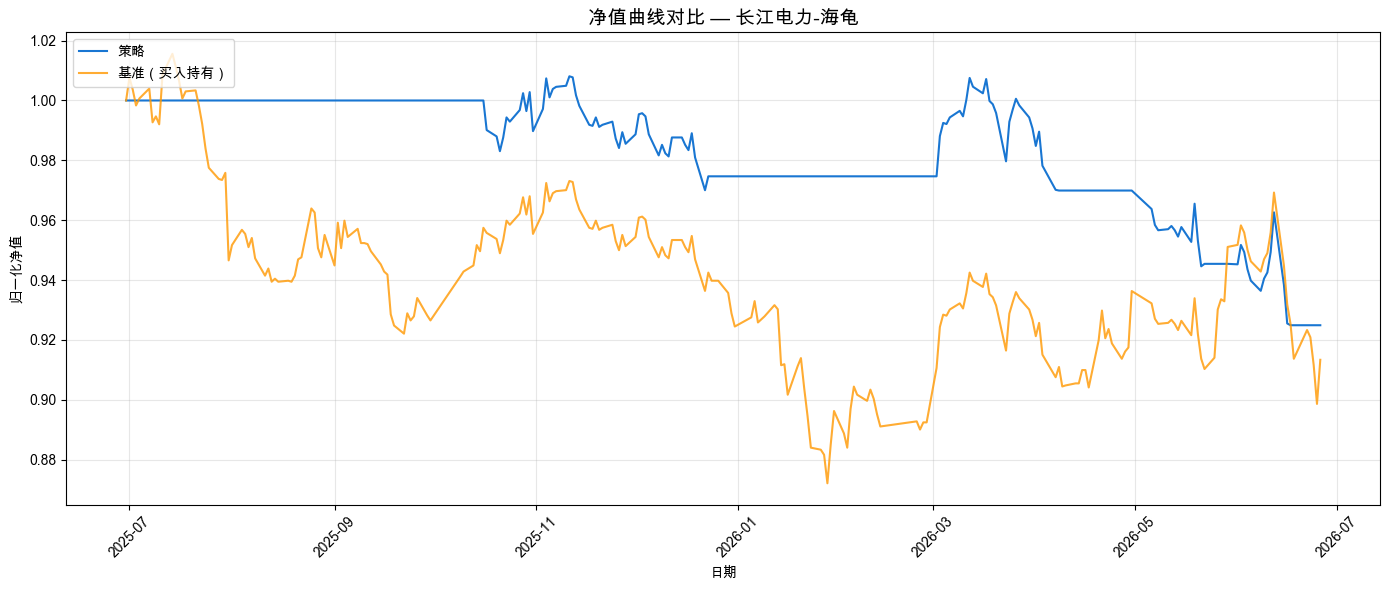

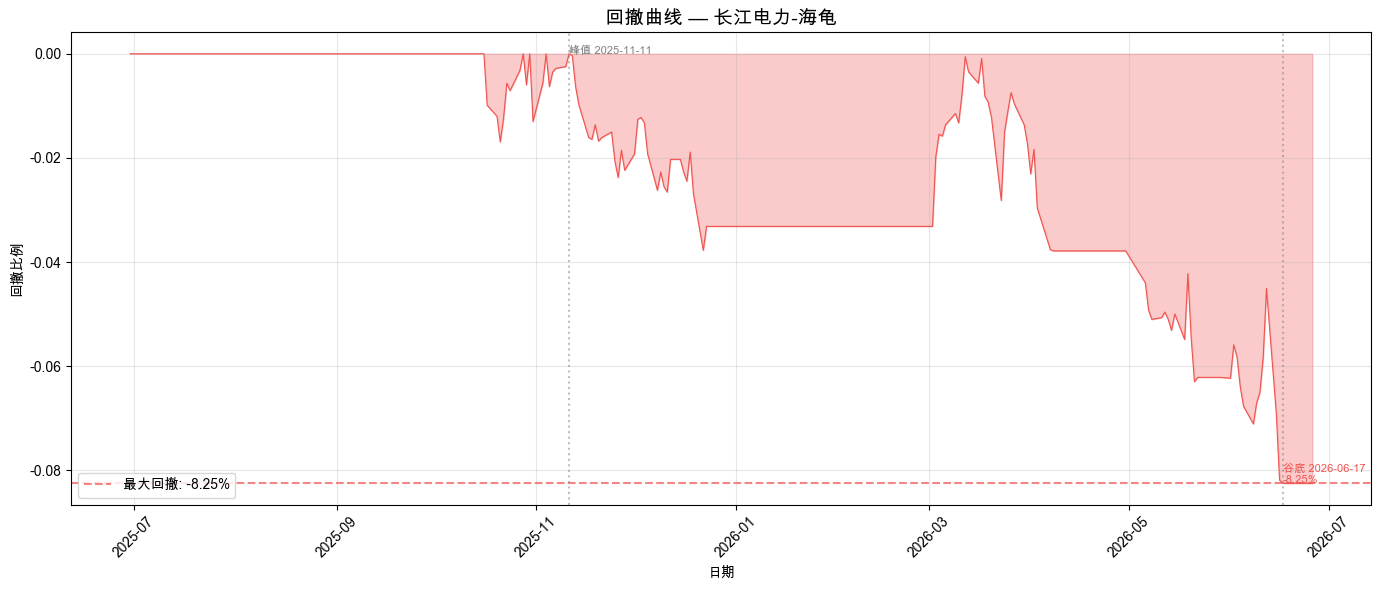

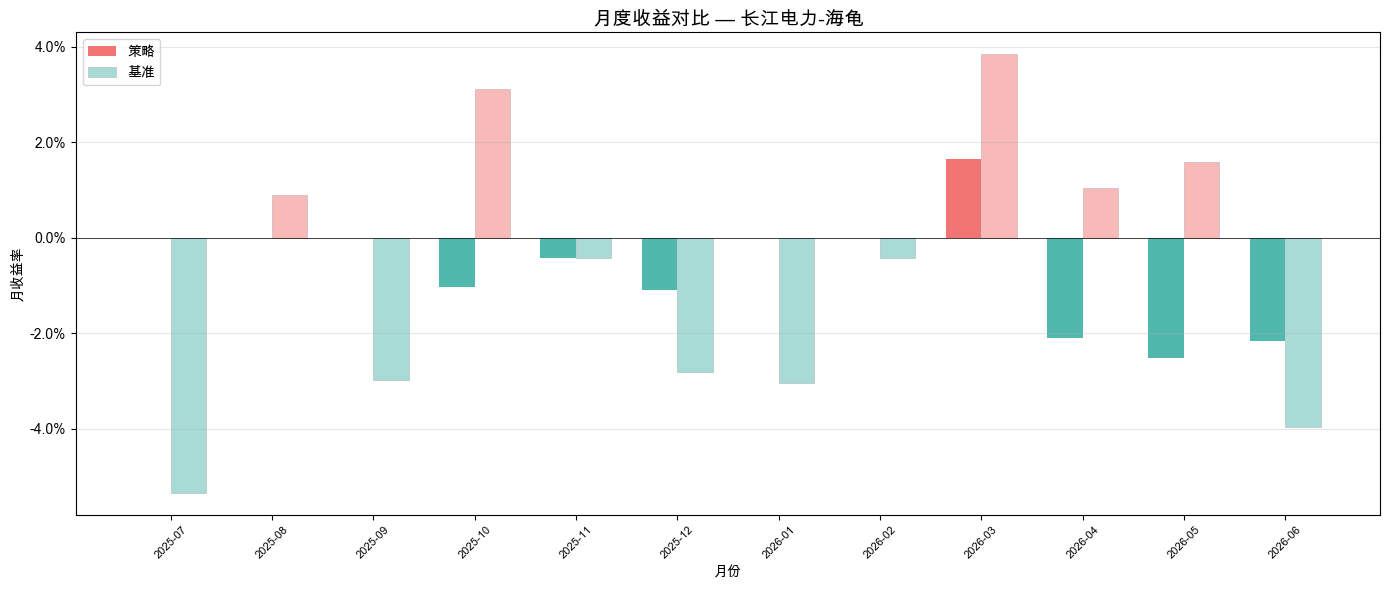

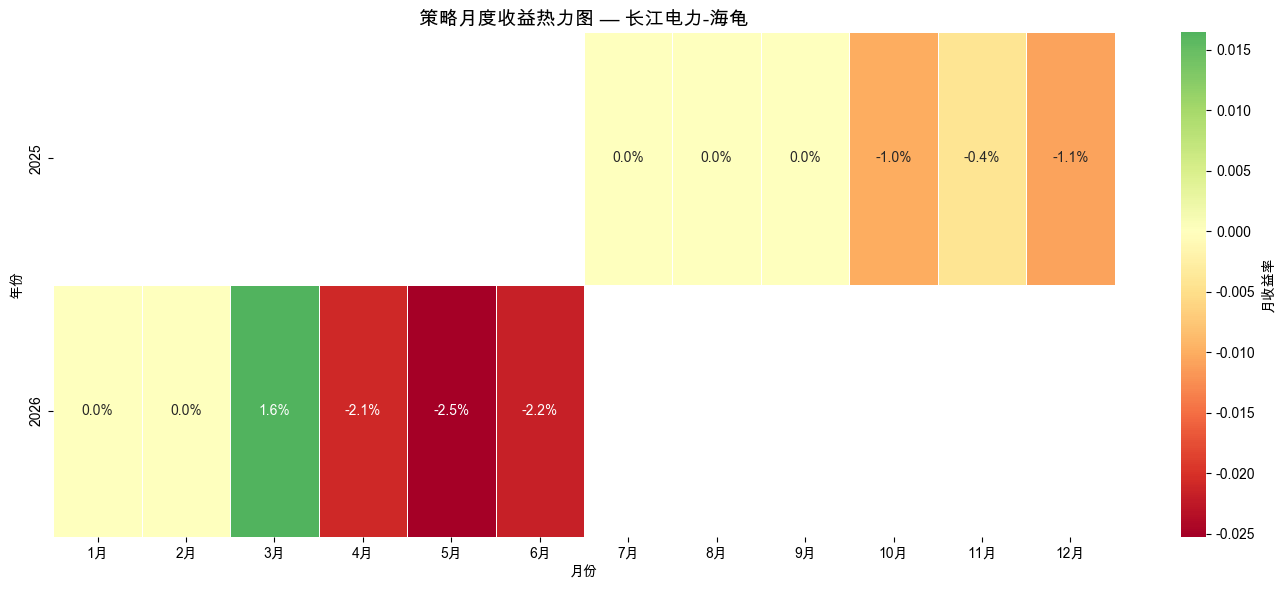

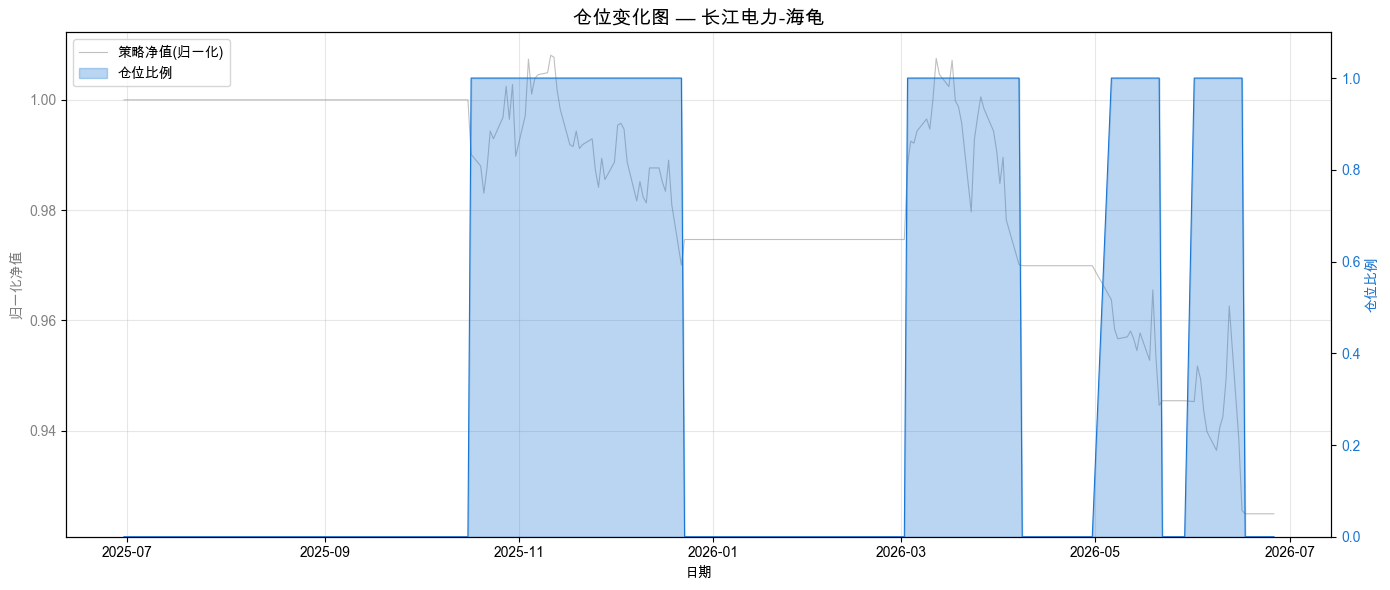

[OK] 长江电力-海龟: 累计=-7.51%  Sharpe=-1.465  MDD=-8.25%  交易=4次


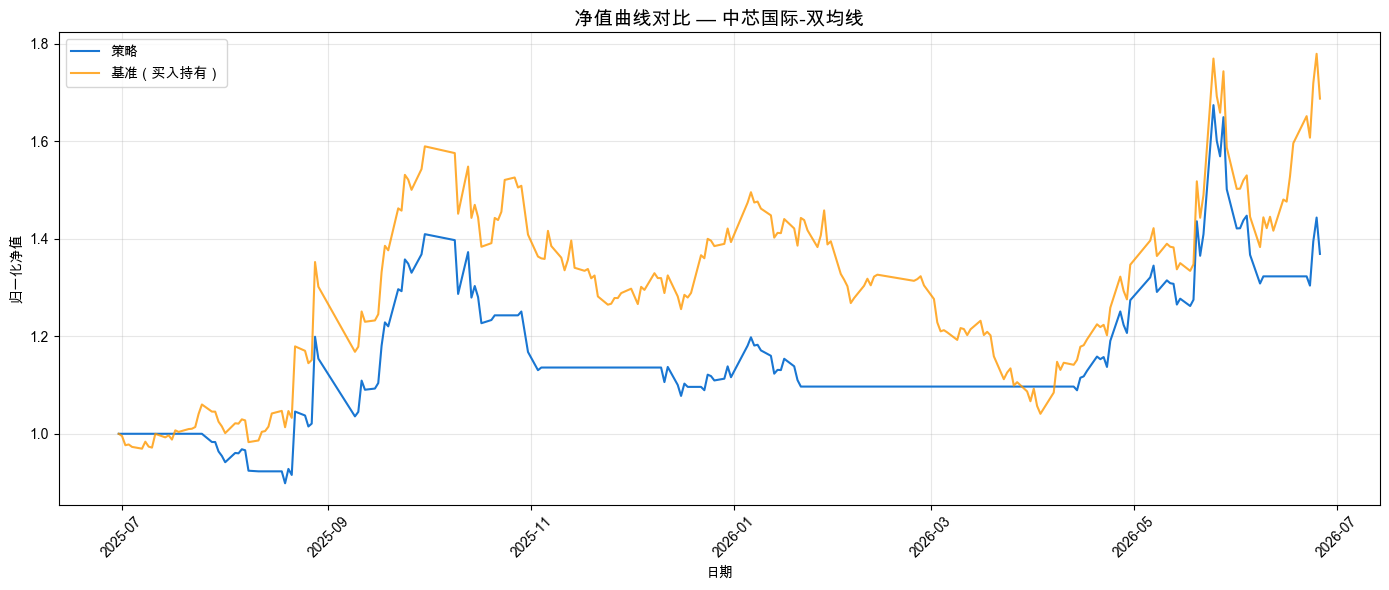

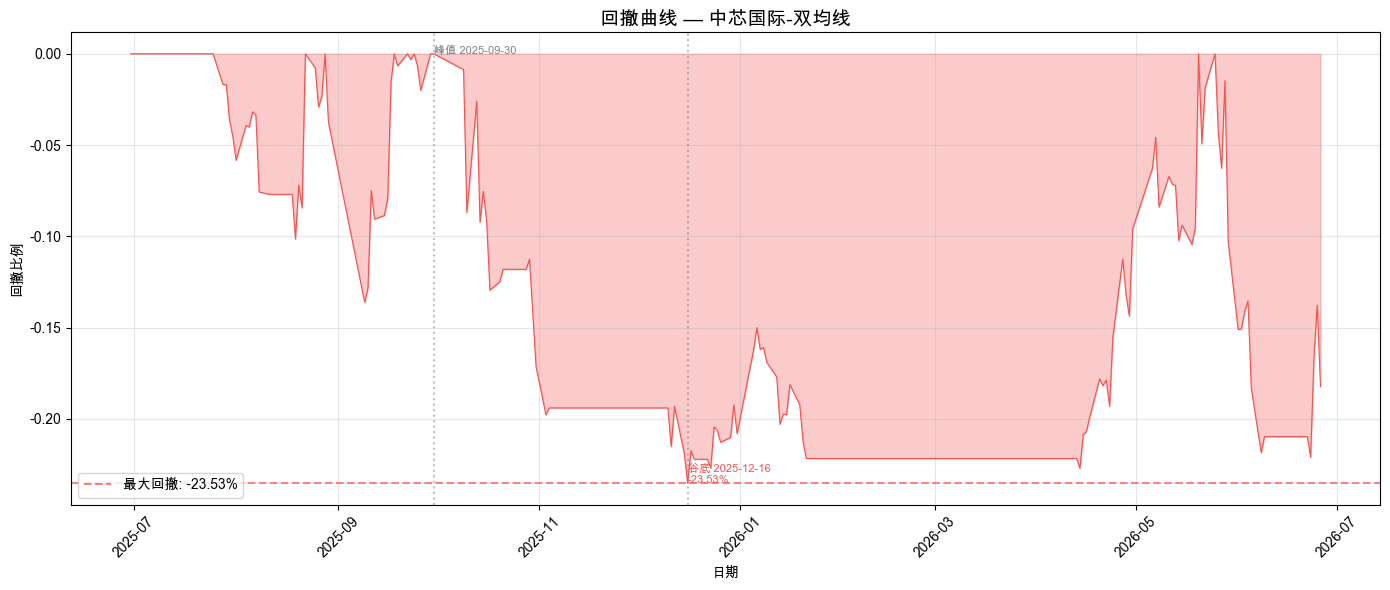

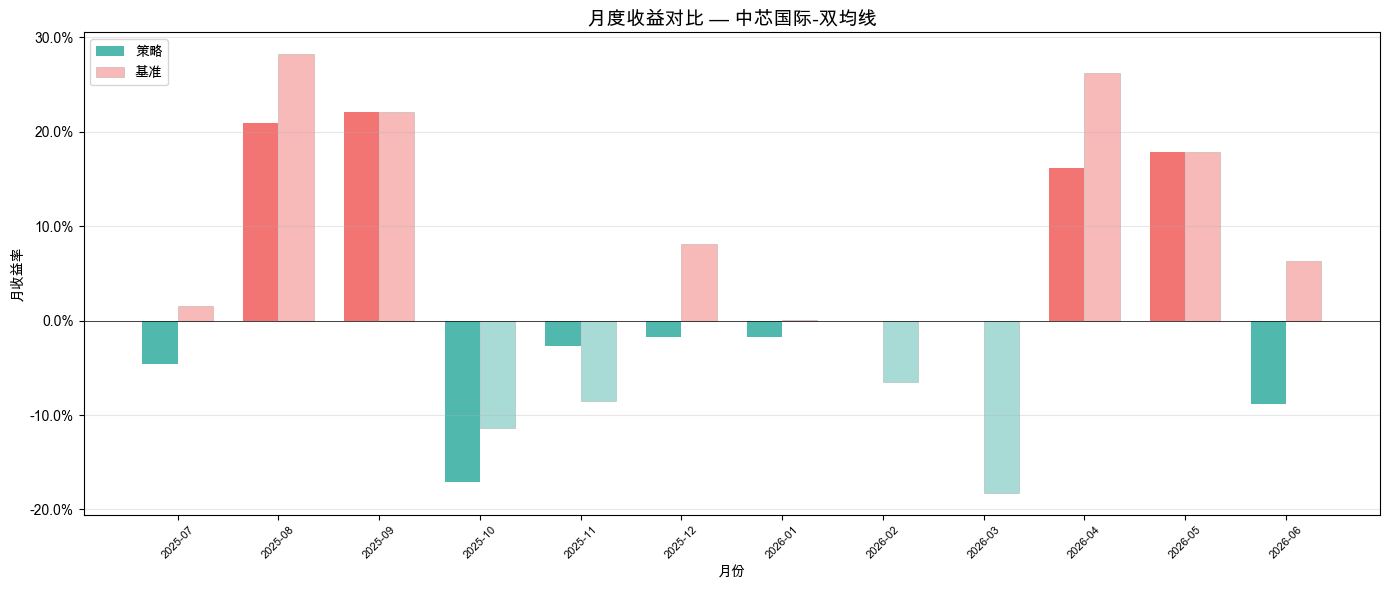

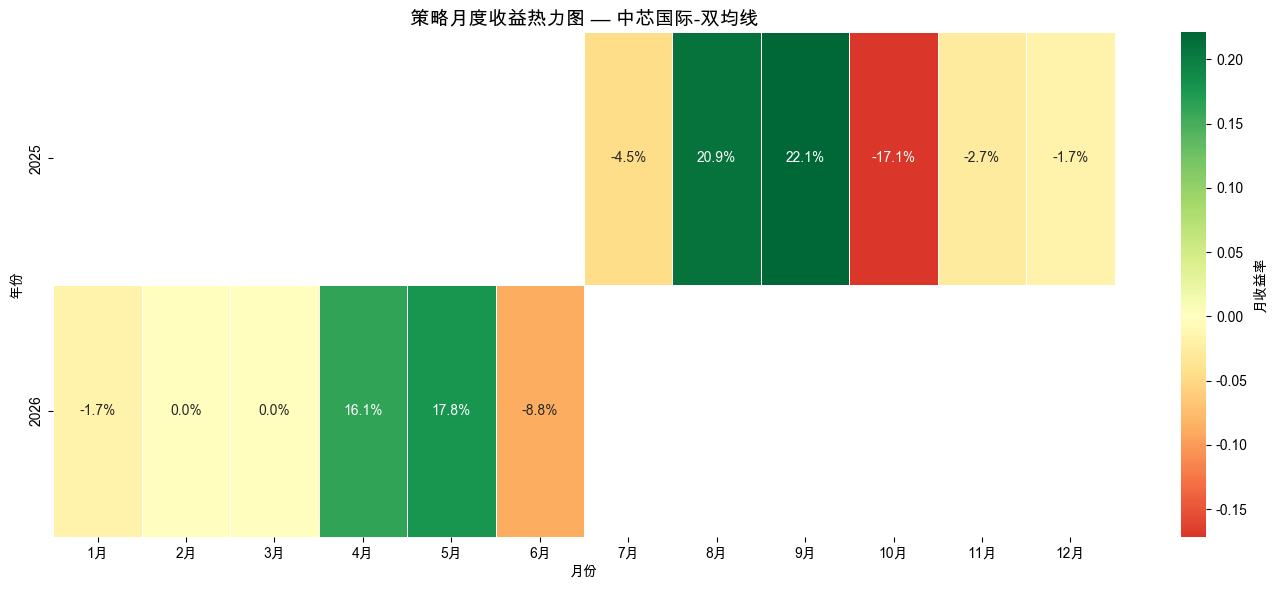

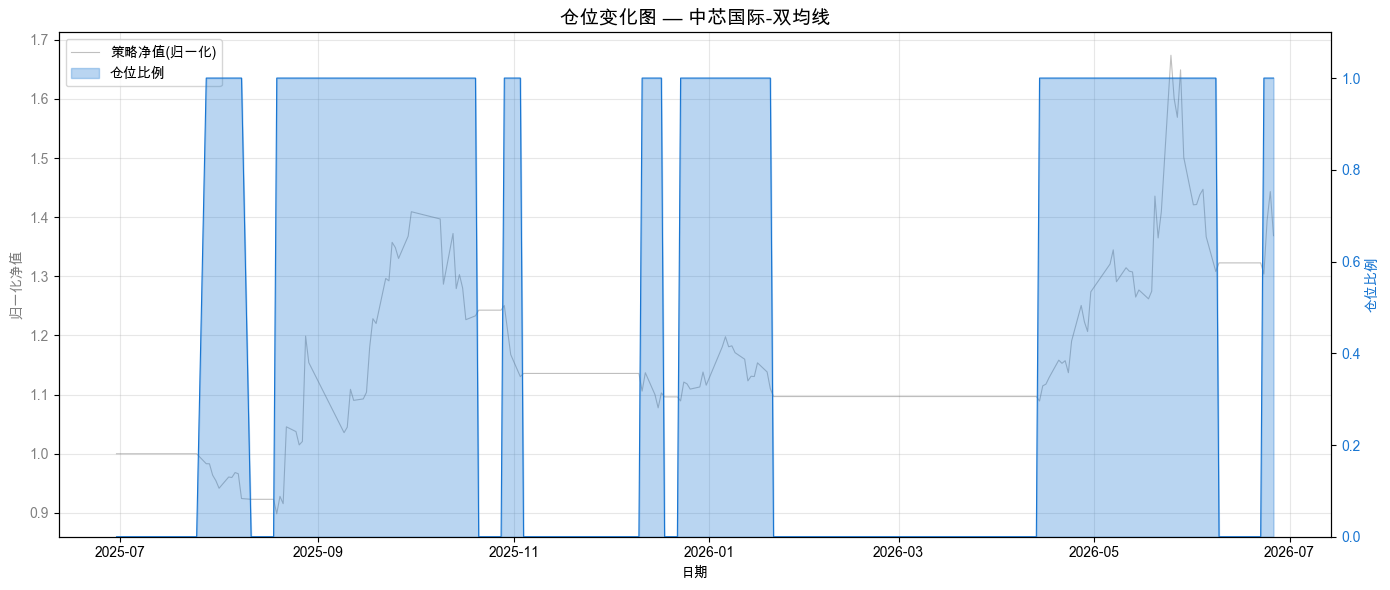

[OK] 中芯国际-双均线: 累计=+36.88%  Sharpe=+0.780  MDD=-23.53%  交易=7次


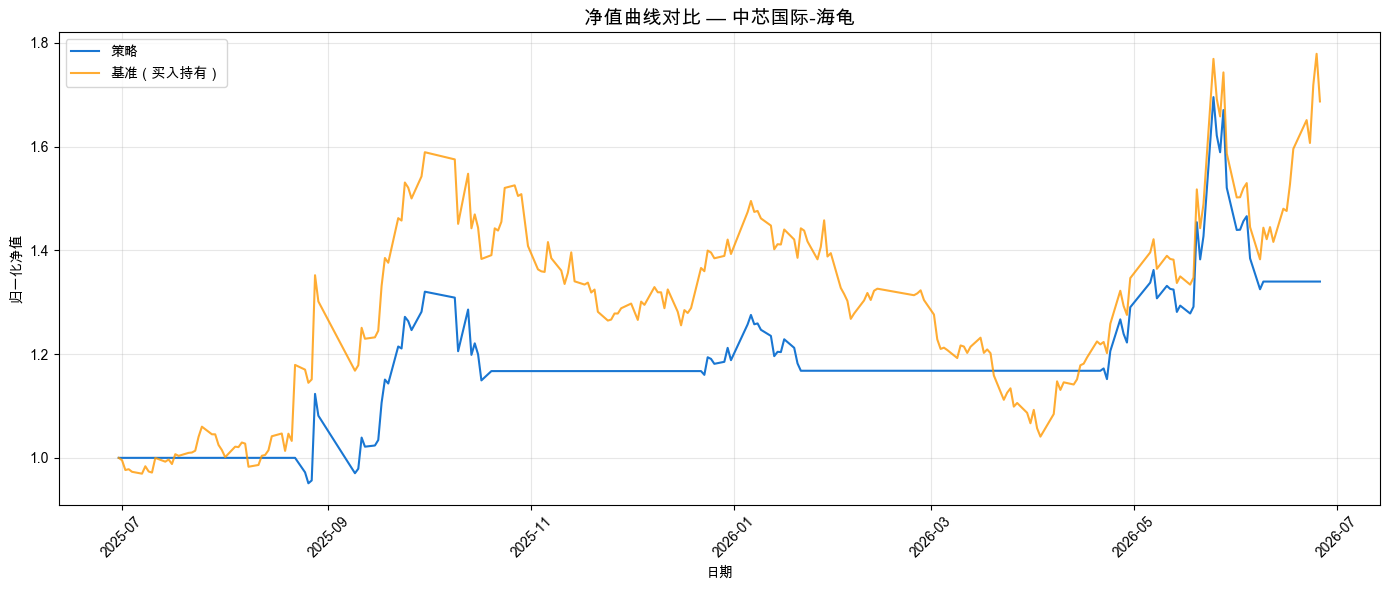

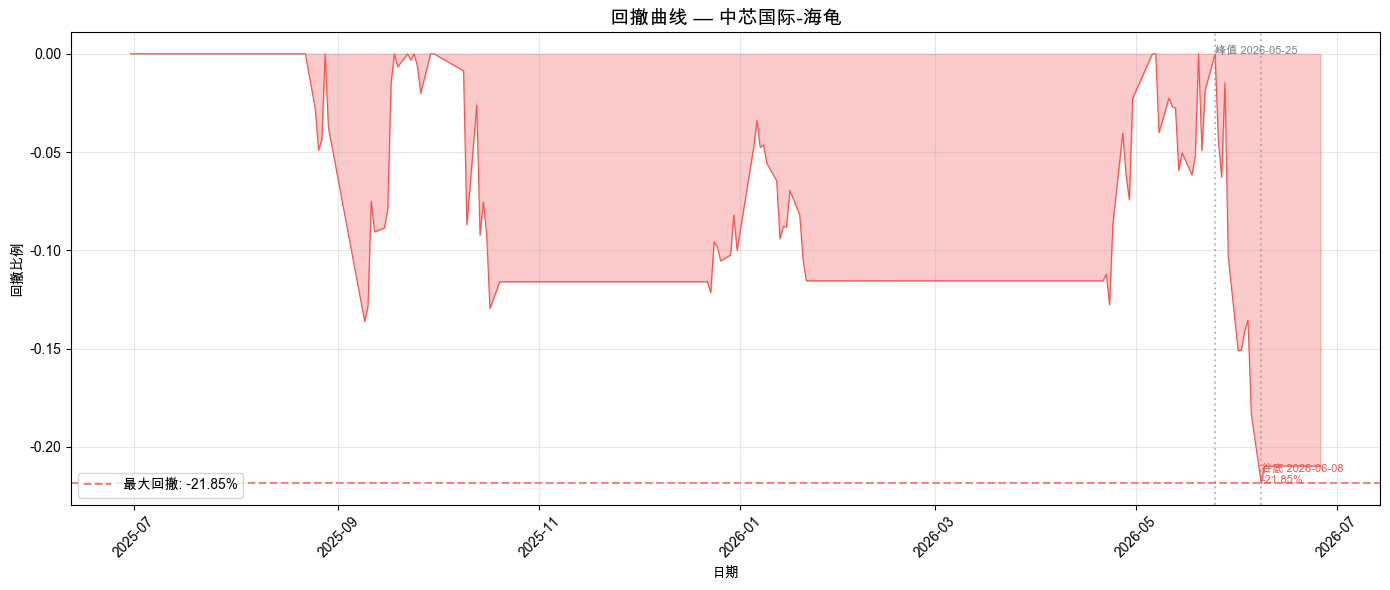

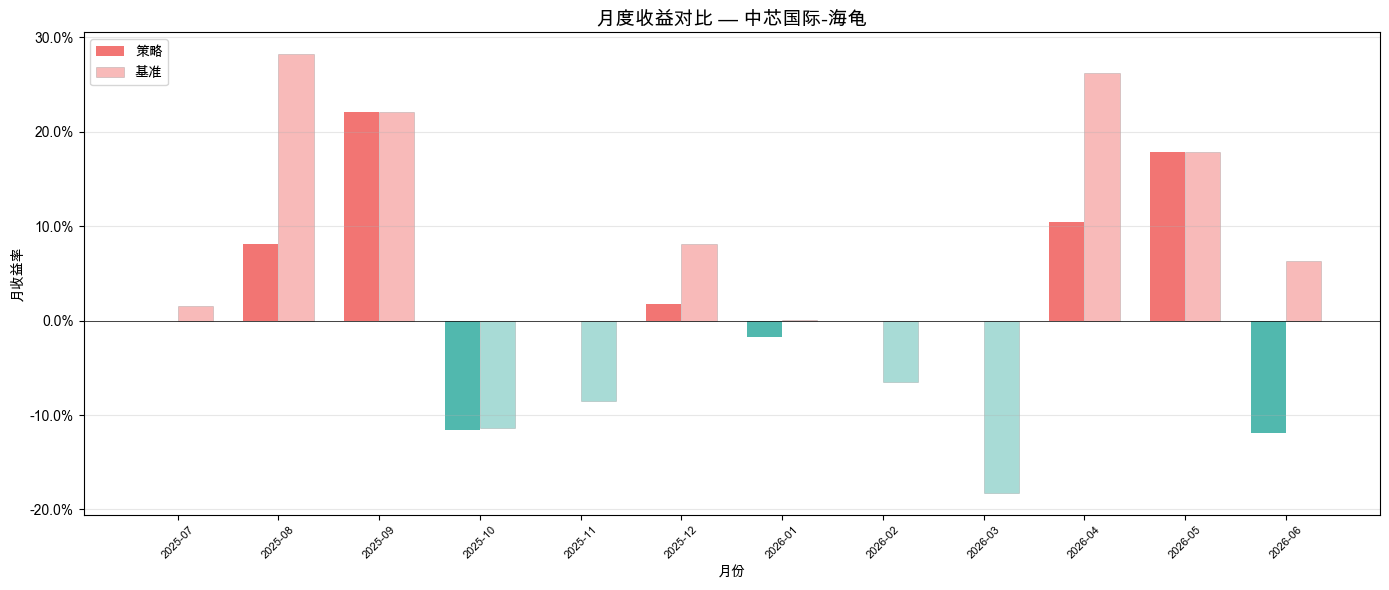

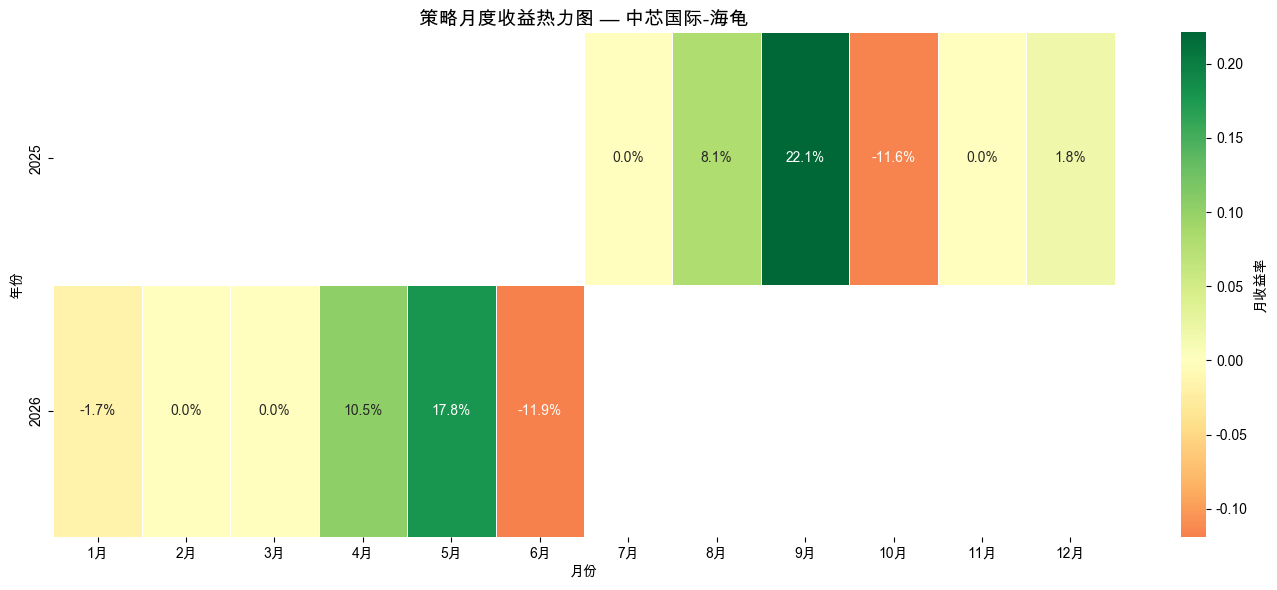

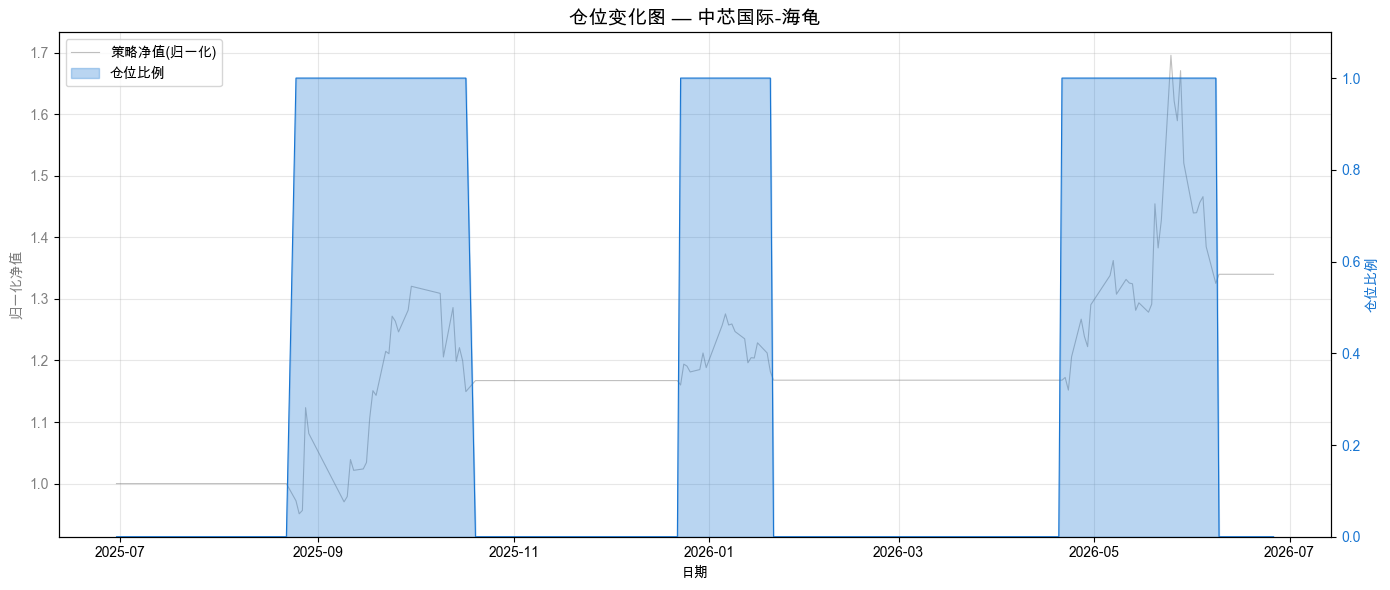

[OK] 中芯国际-海龟: 累计=+33.99%  Sharpe=+0.794  MDD=-21.85%  交易=3次


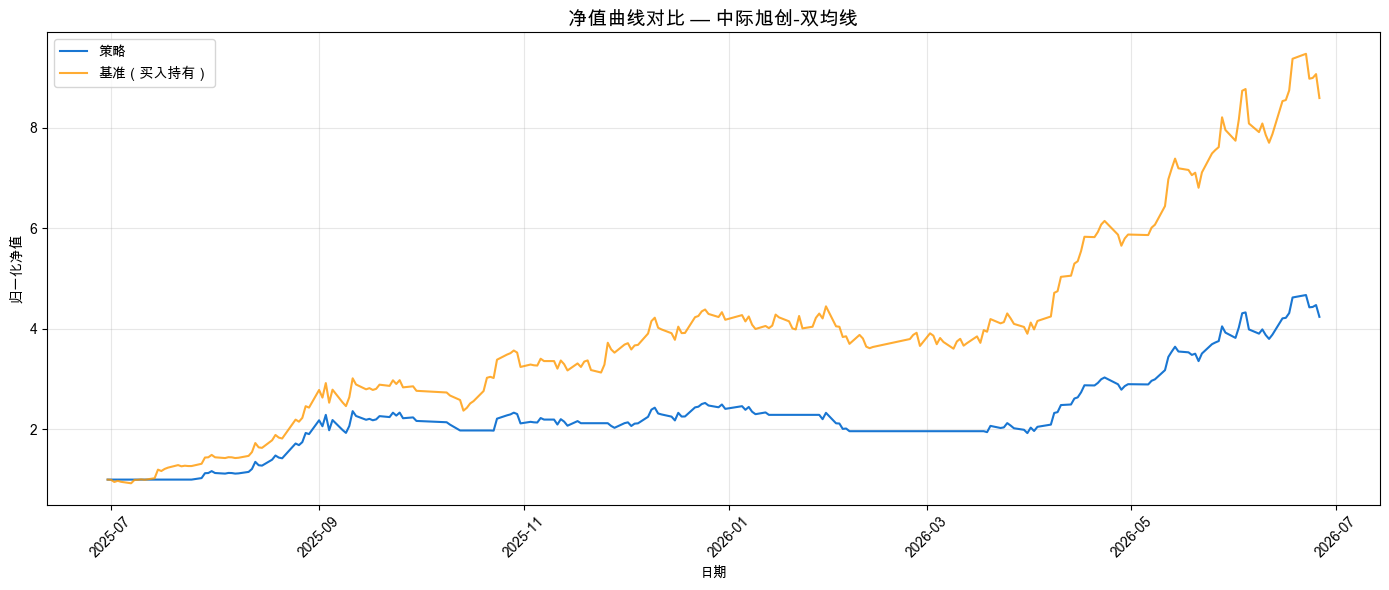

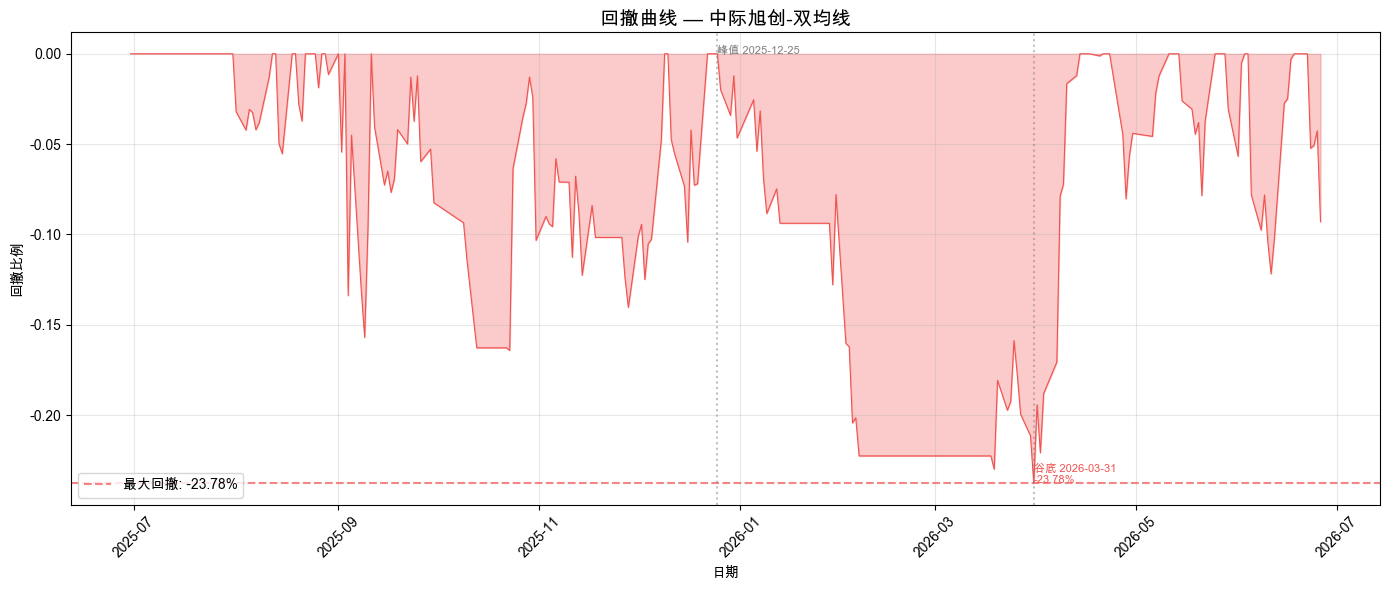

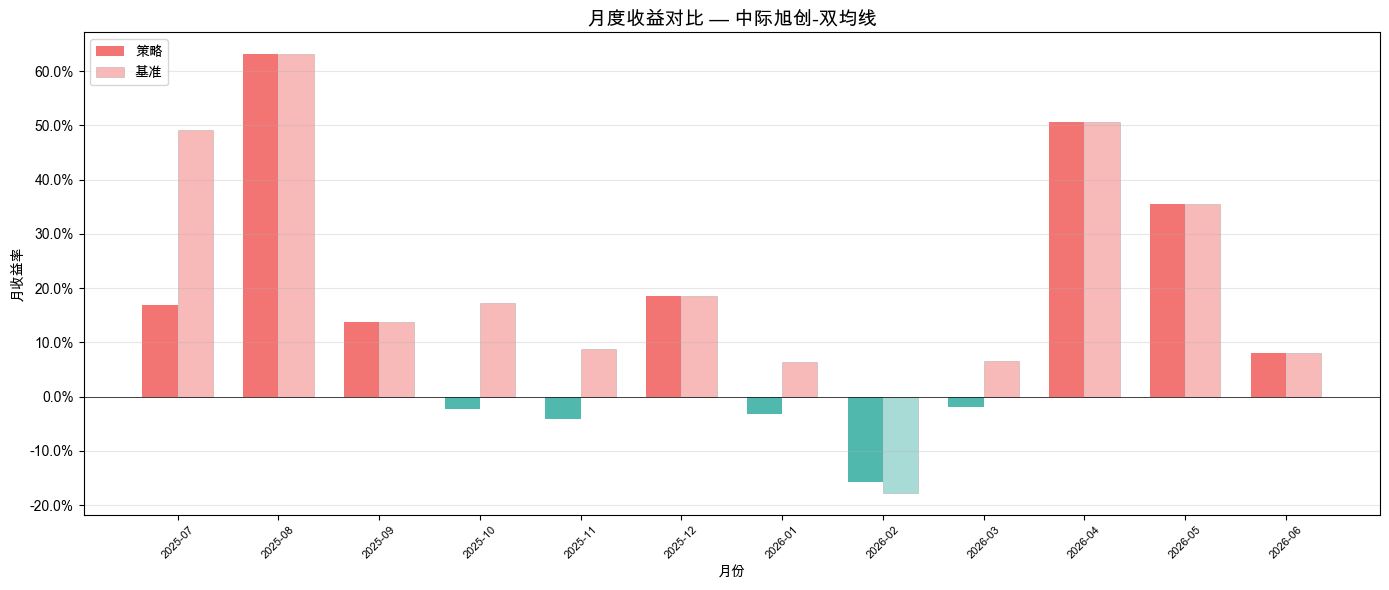

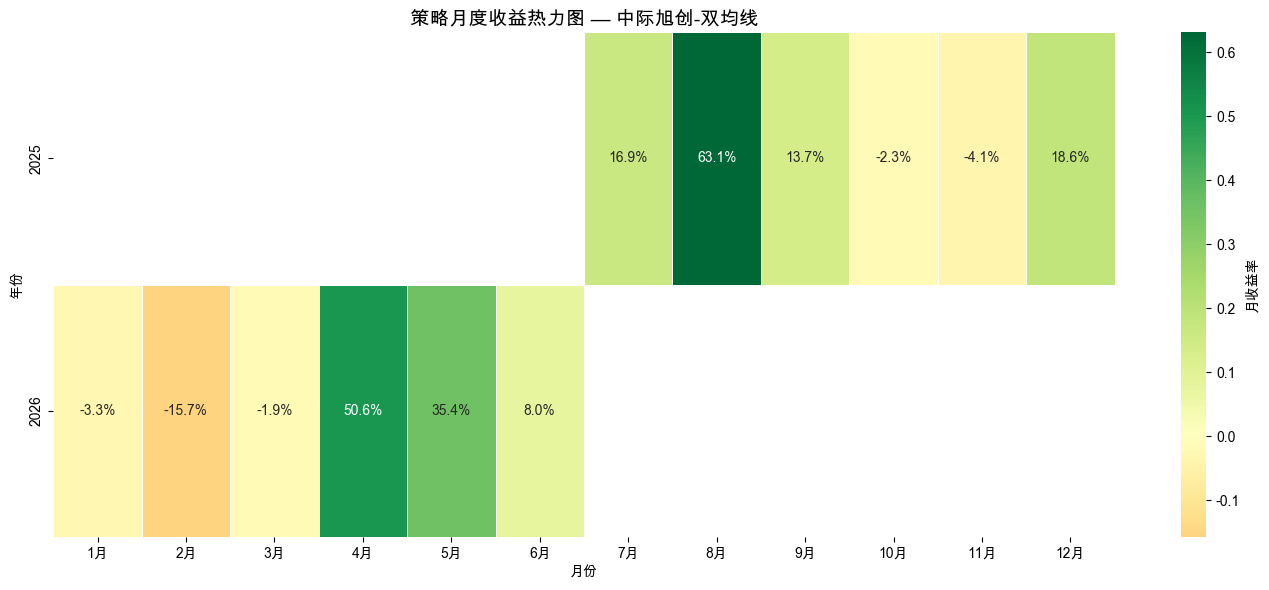

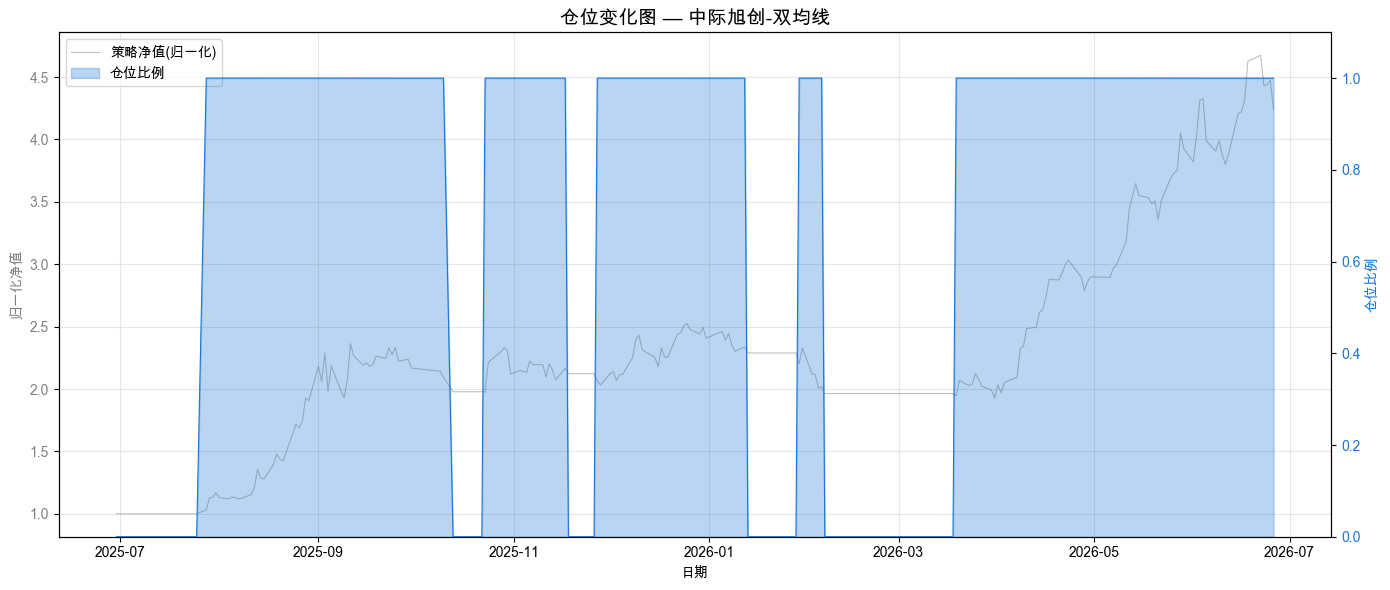

[OK] 中际旭创-双均线: 累计=+324.02%  Sharpe=+5.583  MDD=-23.78%  交易=5次


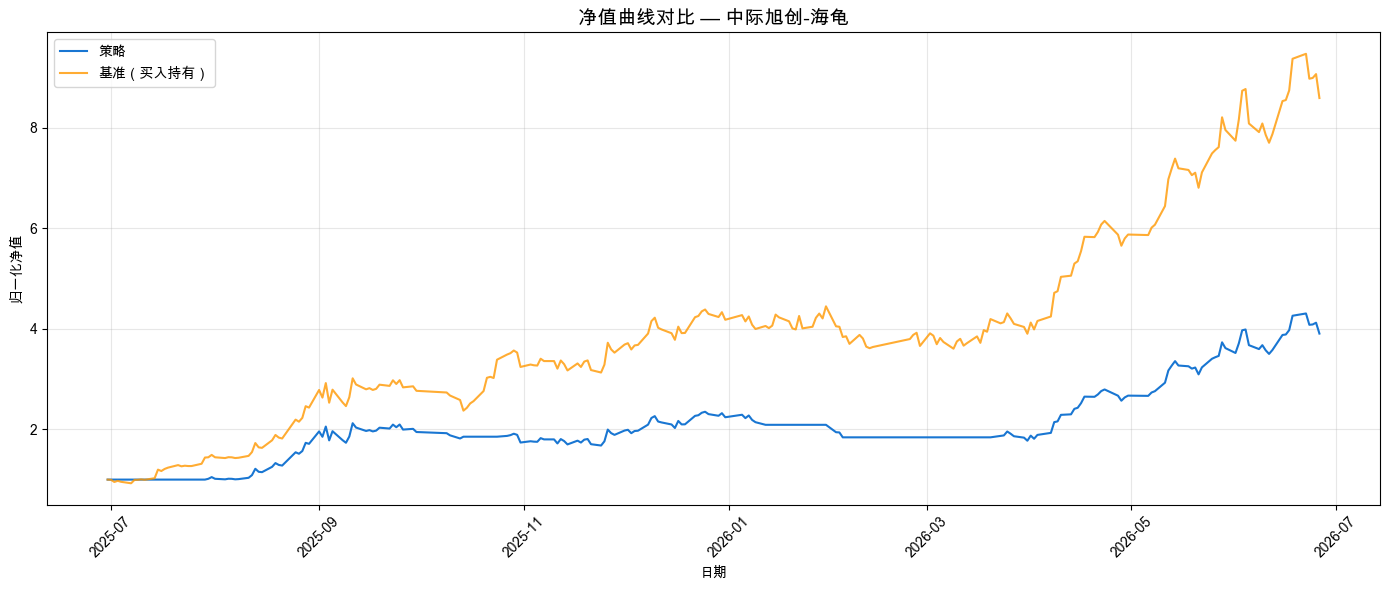

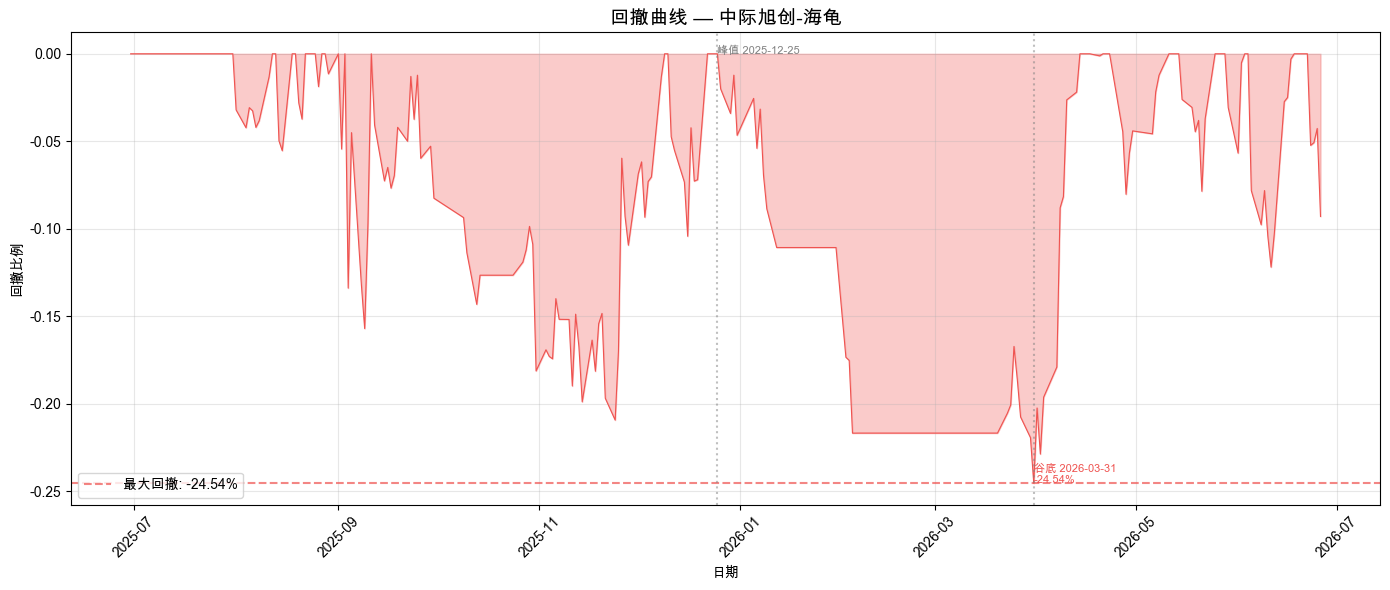

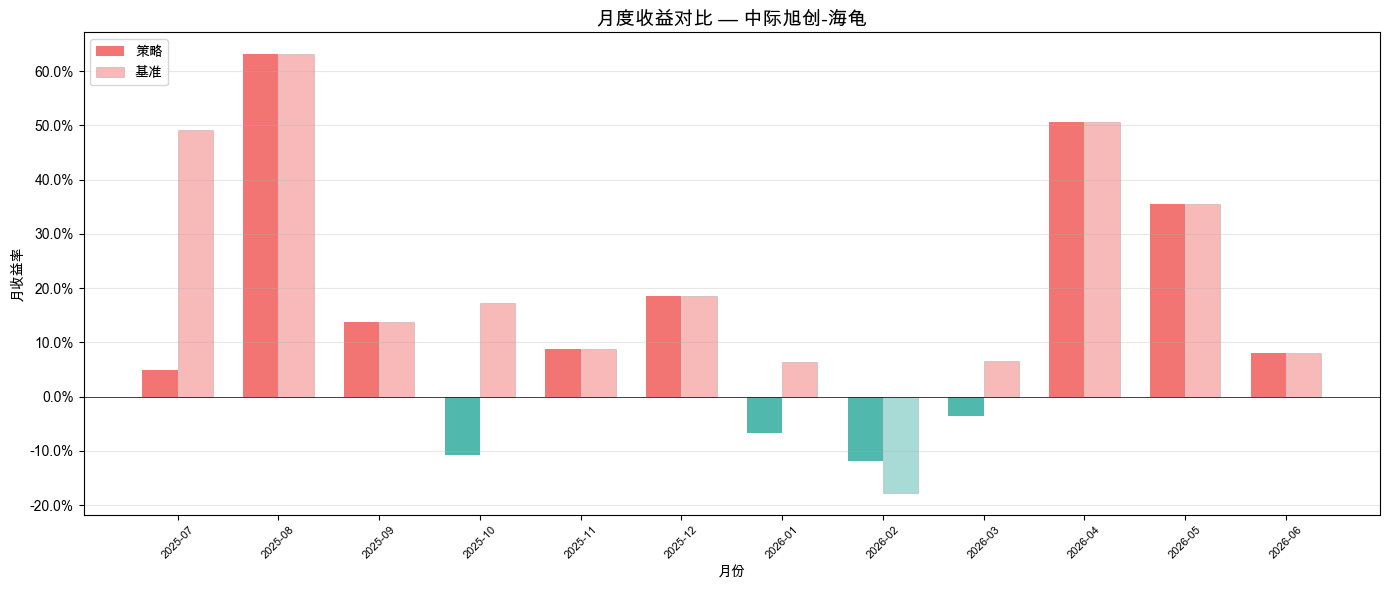

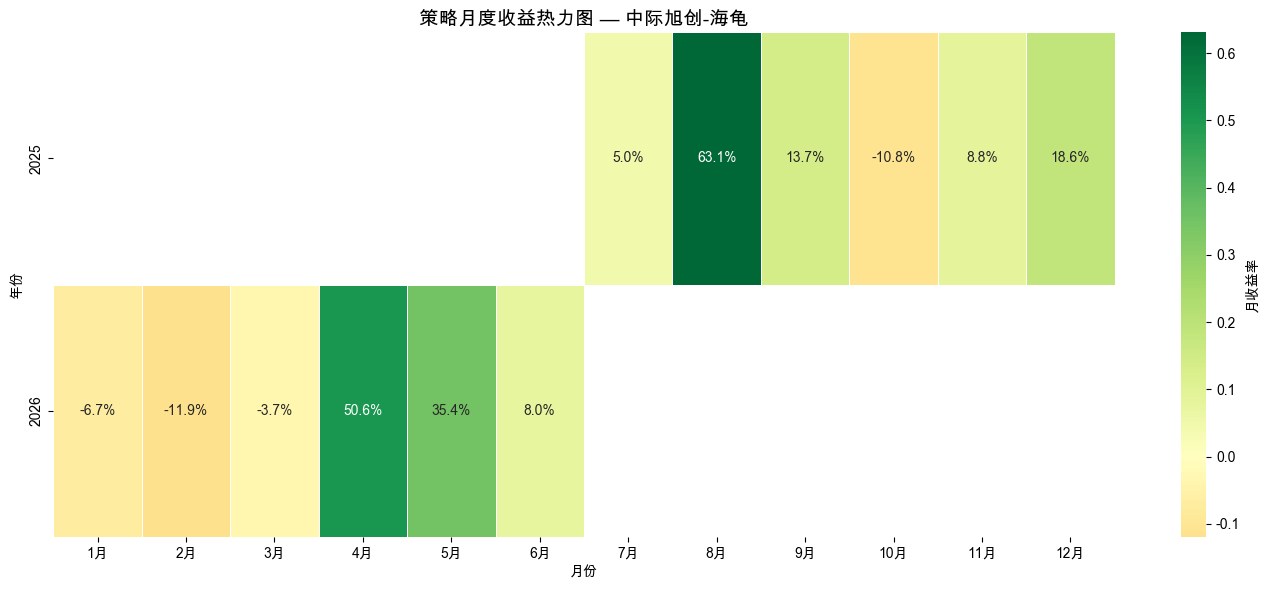

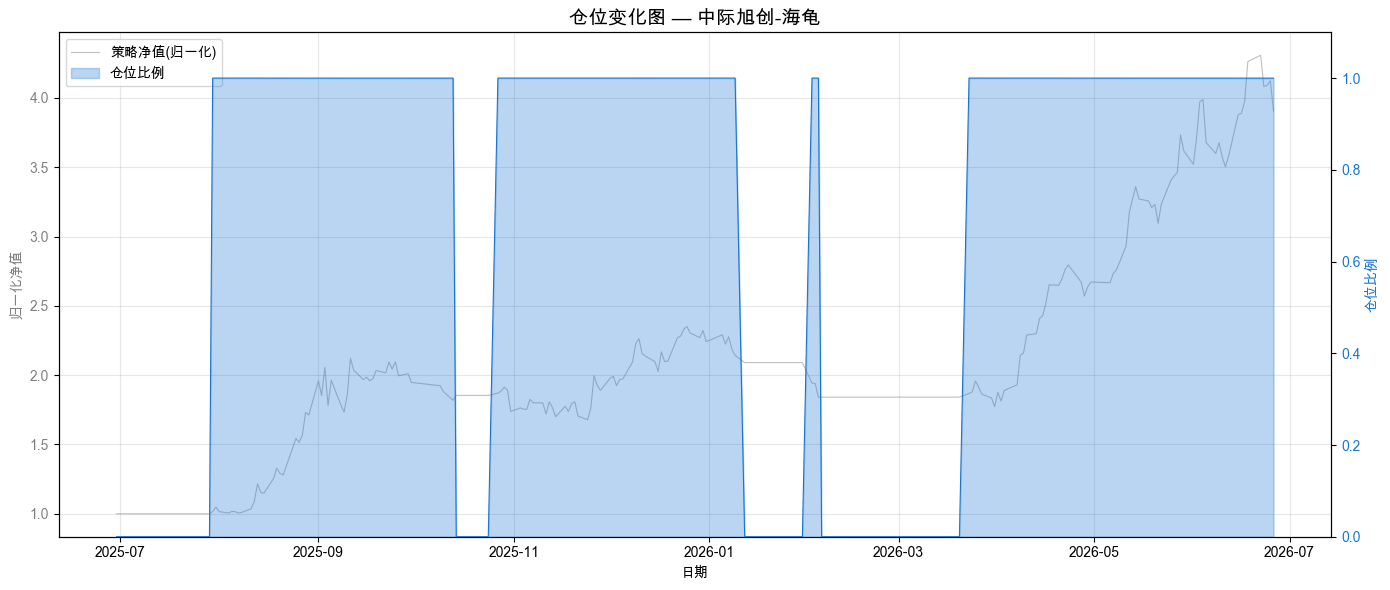

[OK] 中际旭创-海龟: 累计=+290.70%  Sharpe=+5.080  MDD=-24.54%  交易=4次


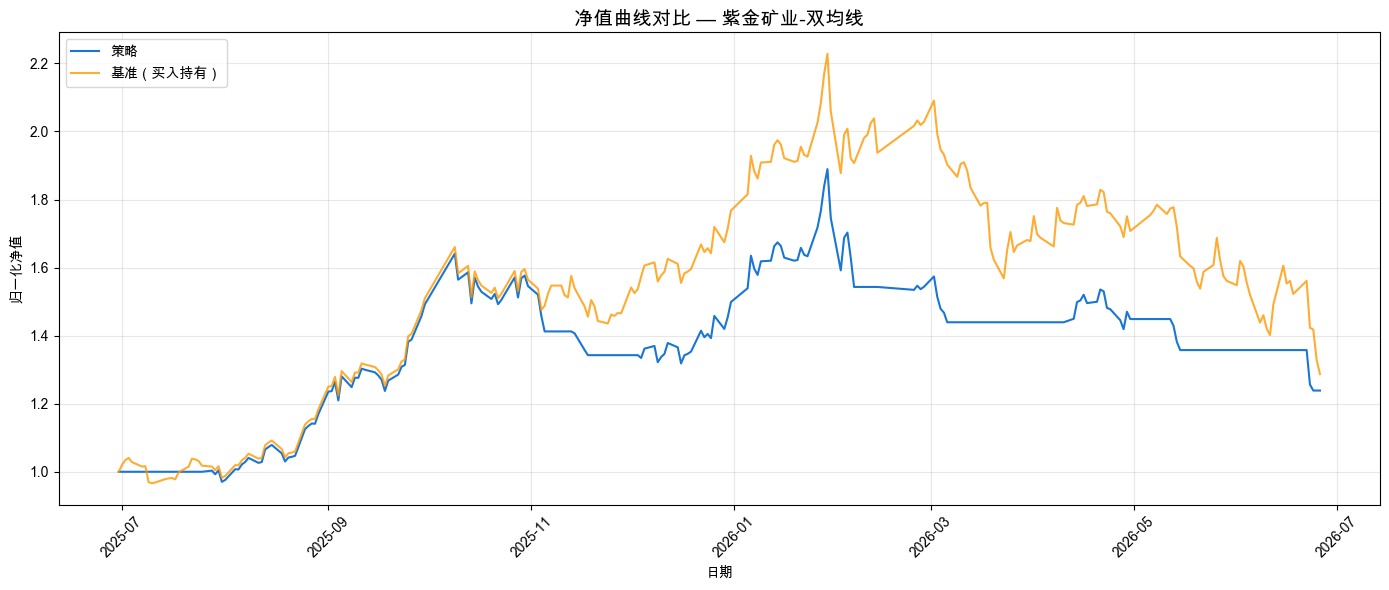

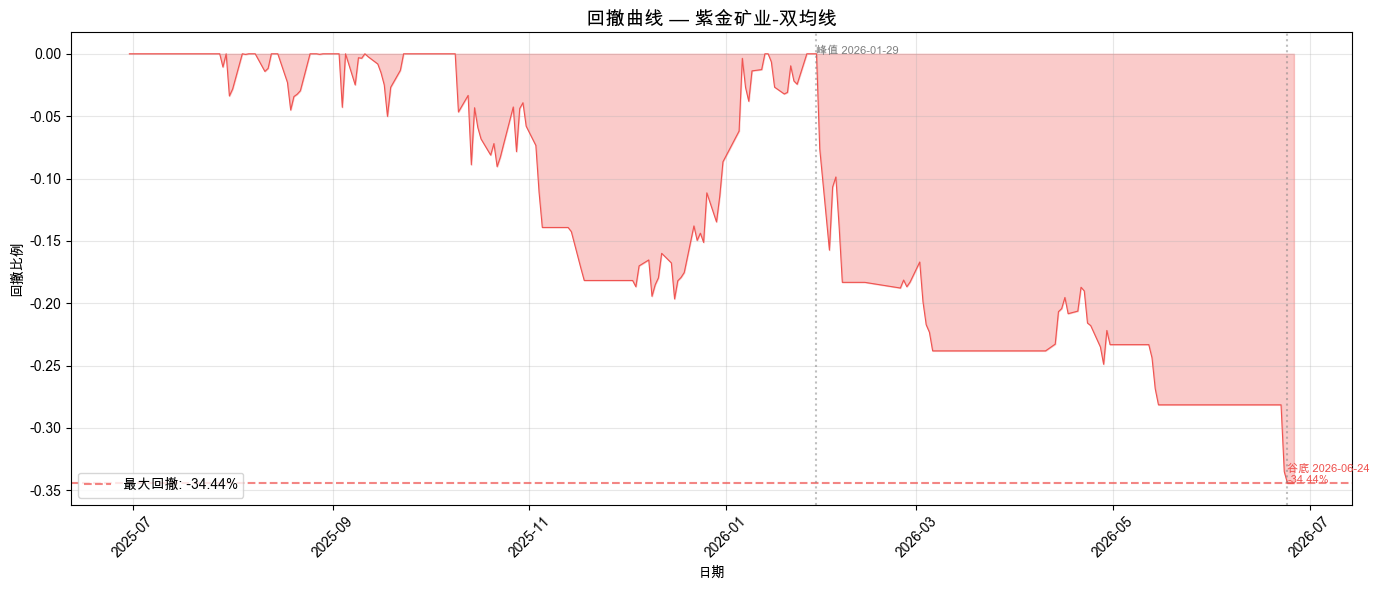

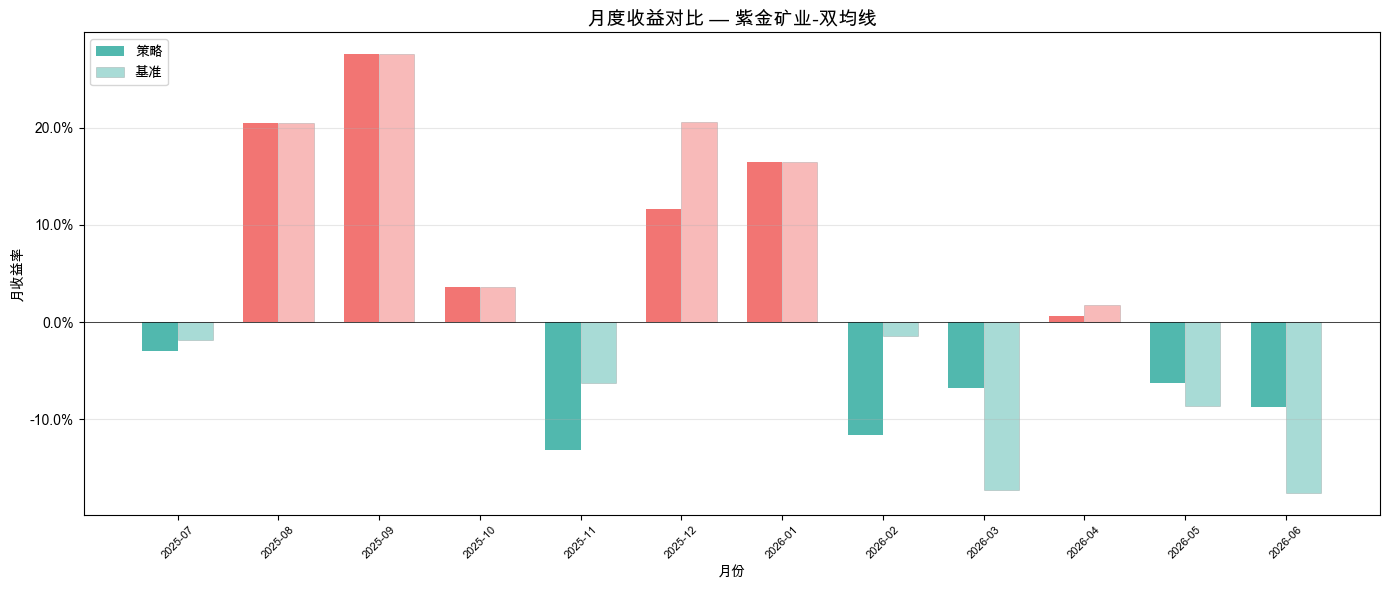

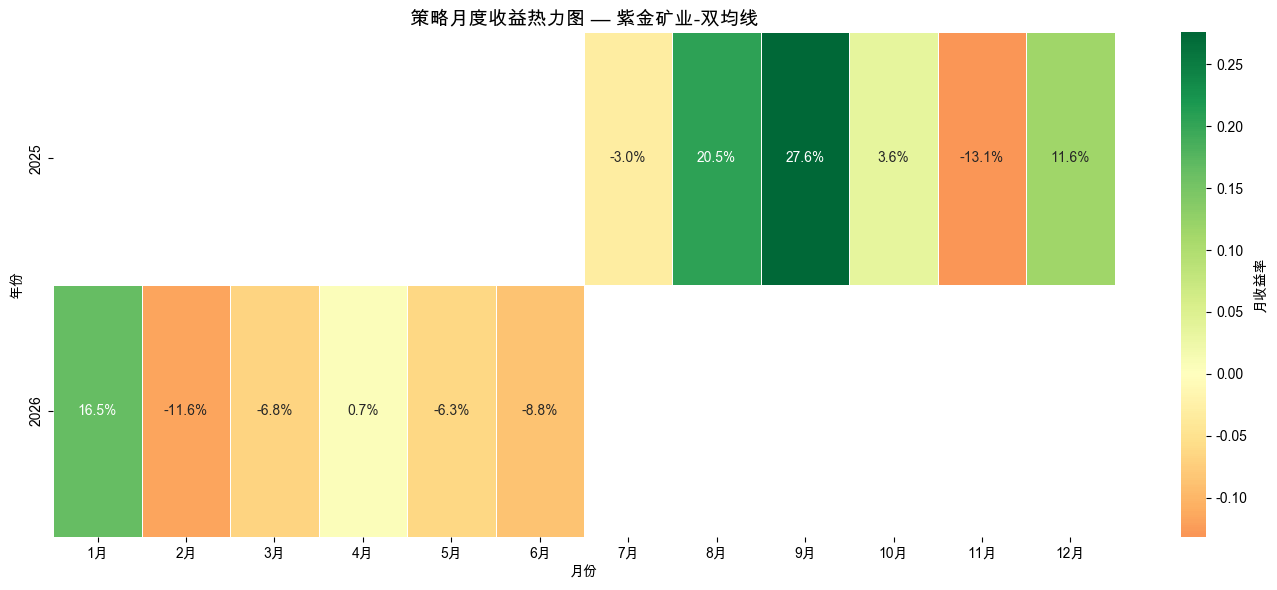

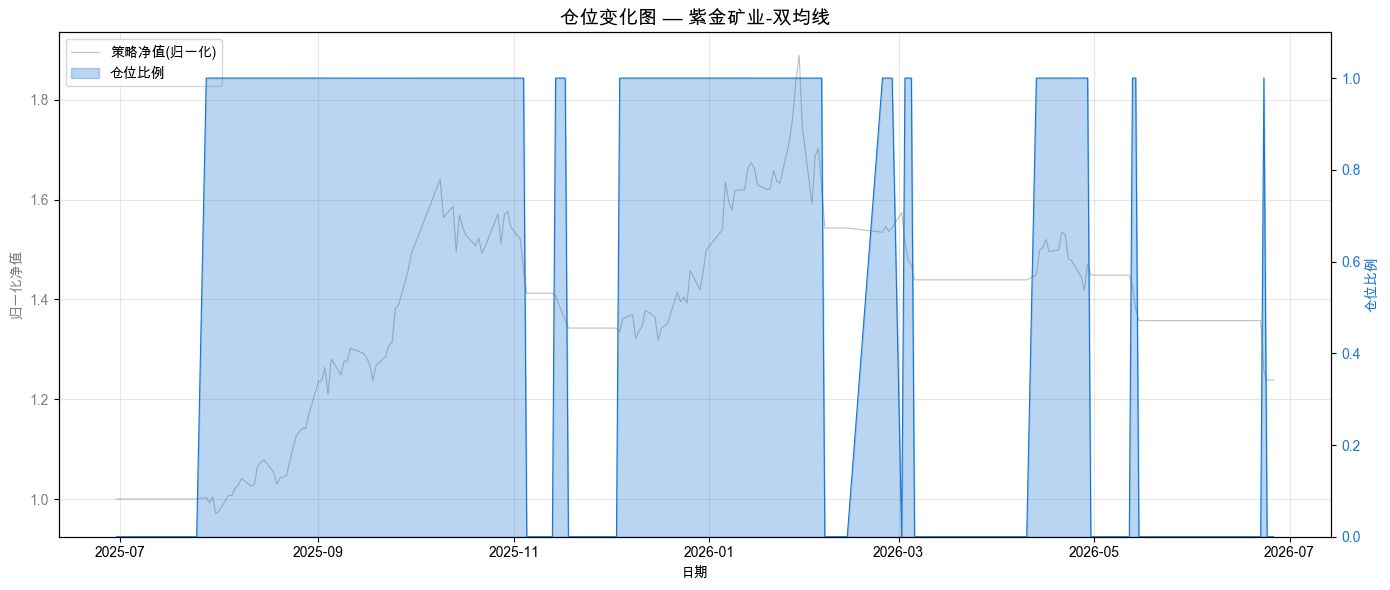

[OK] 紫金矿业-双均线: 累计=+23.87%  Sharpe=+0.648  MDD=-34.44%  交易=8次


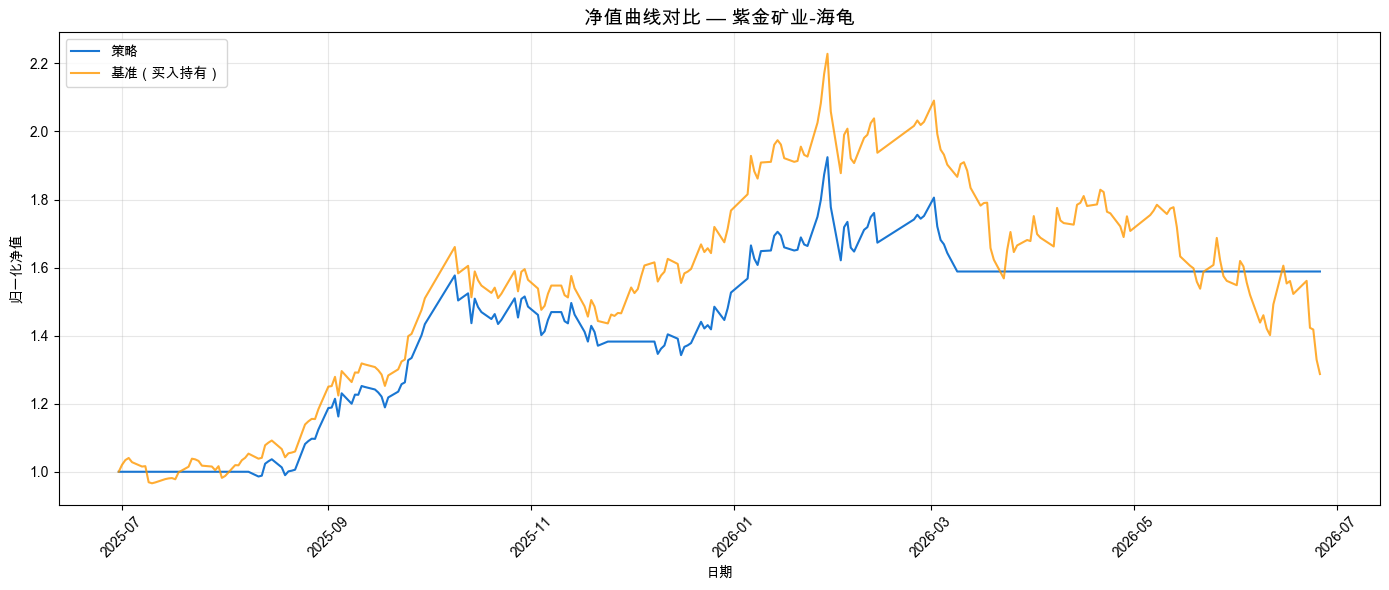

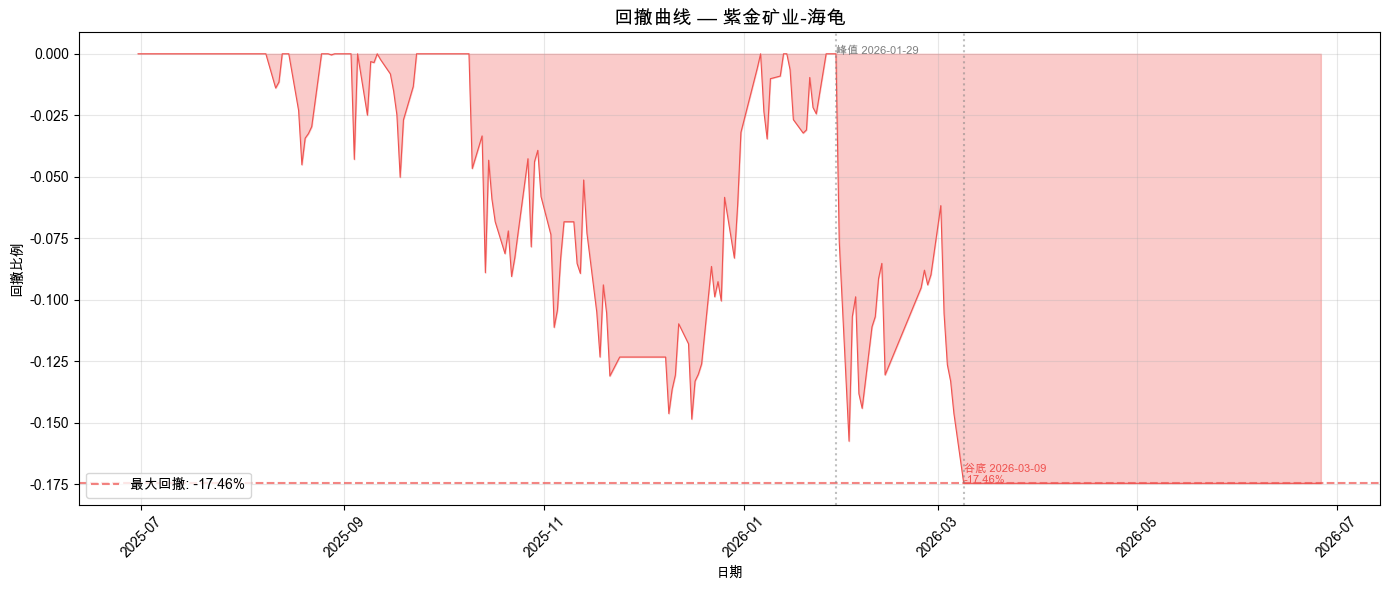

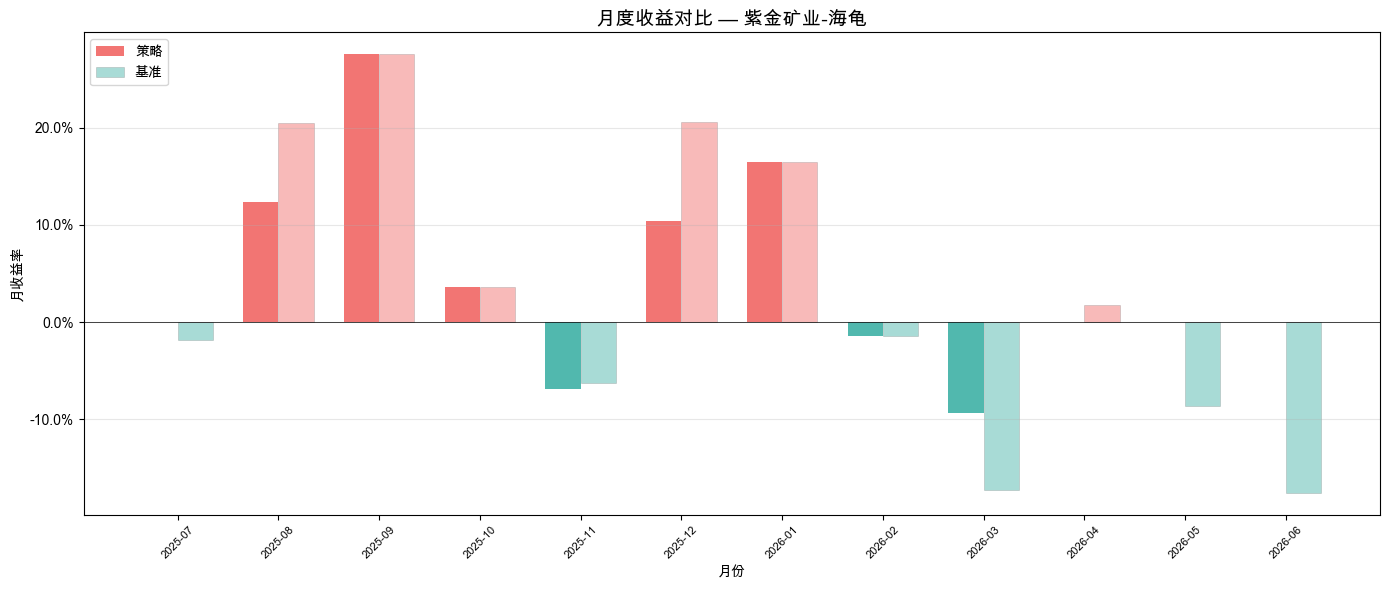

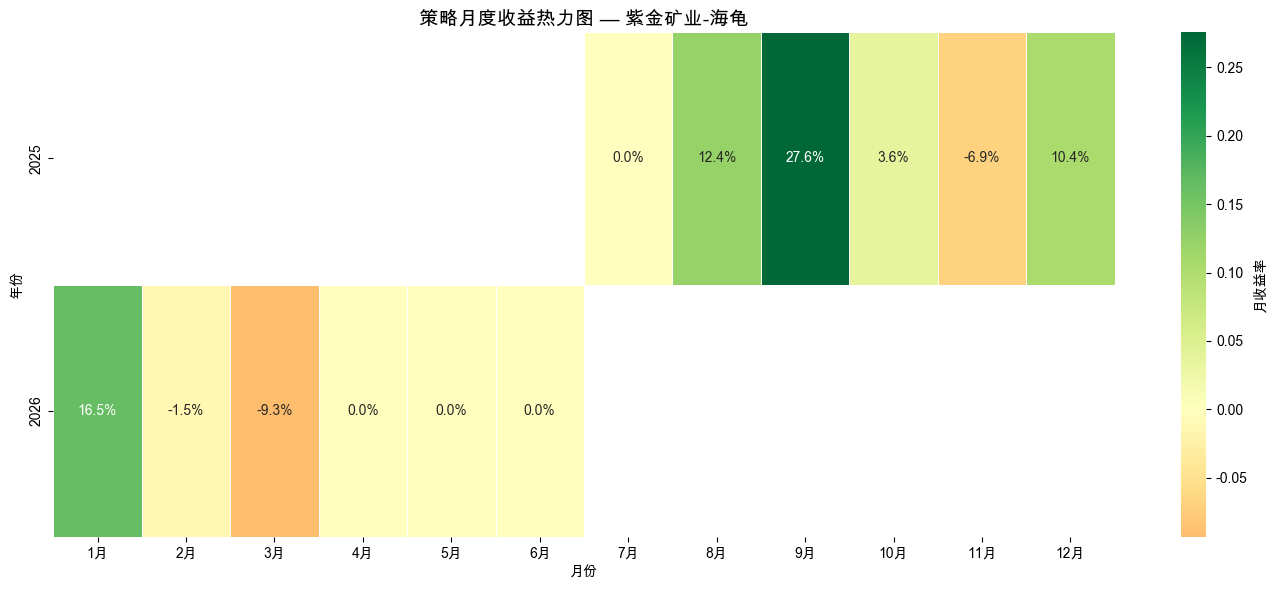

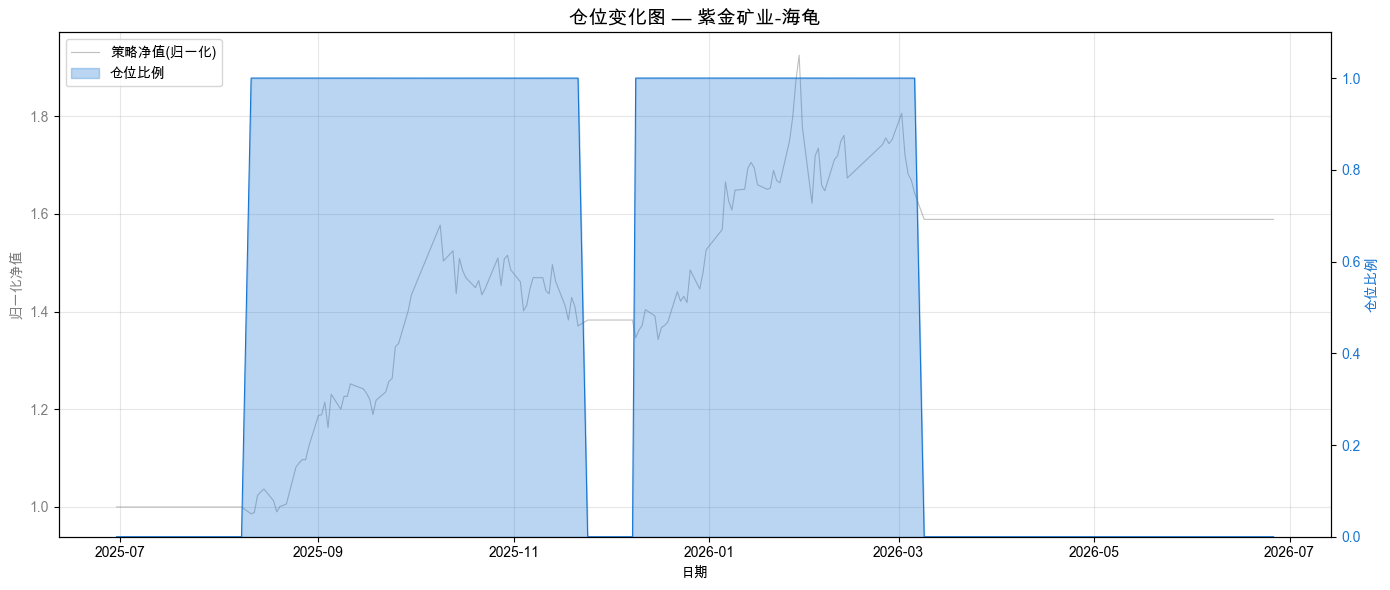

[OK] 紫金矿业-海龟: 累计=+58.85%  Sharpe=+1.745  MDD=-17.46%  交易=2次

共 8 组回测完成，图表输出目录: /Users/stella/Documents/LLM辅助量化交易/result/backtest_charts


In [5]:
engine = BacktestEngine()
results = {}
metrics_rows = []

for stock_name, data in STOCKS.items():
    for strategy_name, (sig_fn, params) in STRATEGIES.items():
        run_name = f'{stock_name}-{strategy_name}'
        try:
            signals = sig_fn(data, params)
            res = engine.run(data, signals, name=run_name)
            results[run_name] = res

            # 单组指标
            ev = Evaluator(res)
            ts_stats = ev._trade_stats()
            metrics_rows.append({
                '组合': run_name,
                '累计收益率': ev._cum_return(res.strategy_nav),
                '基准累计收益率': ev._cum_return(res.benchmark_nav),
                '年化收益率': ev._ann_return(res.strategy_nav),
                '超额年化收益': (ev._ann_return(res.strategy_nav)
                                - ev._ann_return(res.benchmark_nav)),
                'Sharpe': ev._sharpe(res.strategy_returns),
                '最大回撤': ev._max_drawdown(res.strategy_nav)[0],
                '年化波动率': ev._ann_volatility(res.strategy_returns),
                '胜率': ts_stats['win_rate'],
                '盈亏比': ts_stats['profit_loss_ratio'],
                '利润因子': ts_stats['profit_factor'],
                '交易次数': ts_stats['total_trades'],
                '总交易成本': ts_stats['total_cost'],
            })

            # 图表 V1~V5
            chart_dir = os.path.join(CHARTS_DIR, run_name)
            os.makedirs(chart_dir, exist_ok=True)
            viz = Visualizer(res)
            viz.plot_nav(save_path=os.path.join(chart_dir, 'v1_nav.png'))
            viz.plot_drawdown(save_path=os.path.join(chart_dir, 'v2_drawdown.png'))
            viz.plot_monthly_returns(save_path=os.path.join(chart_dir, 'v3_monthly_returns.png'))
            viz.plot_monthly_heatmap(save_path=os.path.join(chart_dir, 'v4_monthly_heatmap.png'))
            viz.plot_positions(save_path=os.path.join(chart_dir, 'v5_positions.png'))

            print(f'[OK] {run_name}: '
                  f'累计={metrics_rows[-1]["累计收益率"]:+.2%}  '
                  f'Sharpe={metrics_rows[-1]["Sharpe"]:+.3f}  '
                  f'MDD={metrics_rows[-1]["最大回撤"]:.2%}  '
                  f'交易={metrics_rows[-1]["交易次数"]}次')
        except Exception as e:
            print(f'[FAIL] {run_name}: {e}')

print(f'\n共 {len(results)} 组回测完成，图表输出目录: {CHARTS_DIR}')


## 6. 逐组绩效评价明细


In [6]:
# 对每组合输出完整 summary_table + monthly_table + monthly_stats
for run_name, res in results.items():
    print(f'\n==========  {run_name}  ==========')
    ev = Evaluator(res)
    ev.summary_table()
    ev.monthly_table()
    ev.monthly_stats()



==========  长江电力-双均线  ==========

  回测绩效汇总  |  策略：长江电力-双均线  |  2025-06-30 ~ 2026-06-26
  类别           指标       策略  基准（买入持有）
  收益        累计收益率 -6.3764%  -8.6619%
            年化收益率 -6.6575%  -9.0388%
         超额收益（年化）  2.3813%         —
  风险        年化波动率  7.6605%  11.9510%
             最大回撤 -6.4161% -14.1262%
         最大回撤持续天数     尚未恢复      尚未恢复
        VaR (95%) -0.7356%  -1.1492%
风险调整 Sharpe Ratio  -1.1301   -0.9237
  交易        总交易次数        6         —
               胜率  0.0000%         —
              盈亏比      inf         —
             利润因子      inf         —
           单笔期望收益     0.00         —
           最大单笔盈利     0.00         —
           最大单笔亏损     0.00         —
           平均持仓天数     24.5         —
            总交易成本 17580.84         —
       交易成本占初始资金比  1.7581%         —


月度收益率表
----------------------------------------------------------------------
     月份   策略月收益率   基准月收益率     超额收益   月内最大回撤
2025-07  0.0000% -5.3409%  5.3409%  0.0000%
2025-08 -1.4793%  0.8980% -2.3773% -2.251

## 7. 8 组横向对比表


In [7]:
compare = pd.DataFrame(metrics_rows)
fmt_cols = {
    '累计收益率': '{:.2%}', '基准累计收益率': '{:.2%}',
    '年化收益率': '{:.2%}', '超额年化收益': '{:.2%}',
    'Sharpe': '{:.3f}', '最大回撤': '{:.2%}', '年化波动率': '{:.2%}',
    '胜率': '{:.2%}', '盈亏比': '{:.3f}', '利润因子': '{:.3f}',
    '总交易成本': '{:,.2f}',
}
styled = compare.style.format({c: f for c, f in fmt_cols.items() if c in compare.columns})
display(styled)

# 落盘
compare.to_csv(os.path.join(PROJECT_ROOT, 'result', 'backtest_comparison.csv'),
               index=False, encoding='utf-8-sig')
print(f'\n对比表已保存: result/backtest_comparison.csv')
print('=== 8 组回测执行完成 ===')


,组合,累计收益率,基准累计收益率,年化收益率,超额年化收益,Sharpe,最大回撤,年化波动率,胜率,盈亏比,利润因子,交易次数,总交易成本
0,长江电力-双均线,-6.38%,-8.66%,-6.66%,2.38%,-1.130,-6.42%,7.66%,33.33%,0.449,0.225,6,"17,580.84"
1,长江电力-海龟,-7.51%,-8.66%,-7.84%,1.20%,-1.465,-8.25%,6.71%,0.00%,0.000,0.000,4,"11,549.22"
2,中芯国际-双均线,36.88%,68.72%,40.02%,-35.21%,0.780,-23.53%,48.75%,42.86%,3.356,2.517,7,"21,720.67"
3,中芯国际-海龟,33.99%,68.72%,36.86%,-38.37%,0.794,-21.85%,43.89%,66.67%,99.498,198.996,3,"10,610.54"
4,中际旭创-双均线,324.02%,759.65%,352.92%,-495.43%,5.583,-23.78%,62.86%,80.00%,2.688,10.753,5,"26,332.19"
5,中际旭创-海龟,290.70%,759.65%,315.78%,-532.57%,5.080,-24.54%,61.77%,75.00%,4.135,12.406,4,"18,623.83"
6,紫金矿业-双均线,23.87%,28.72%,25.08%,-5.12%,0.648,-34.44%,35.60%,50.00%,1.508,1.508,8,"33,802.23"
7,紫金矿业-海龟,58.85%,28.72%,62.24%,32.03%,1.745,-17.46%,34.53%,100.00%,inf,inf,2,"8,185.52"



对比表已保存: result/backtest_comparison.csv
=== 8 组回测执行完成 ===


## 8. 长江电力 - 交易信号可视化


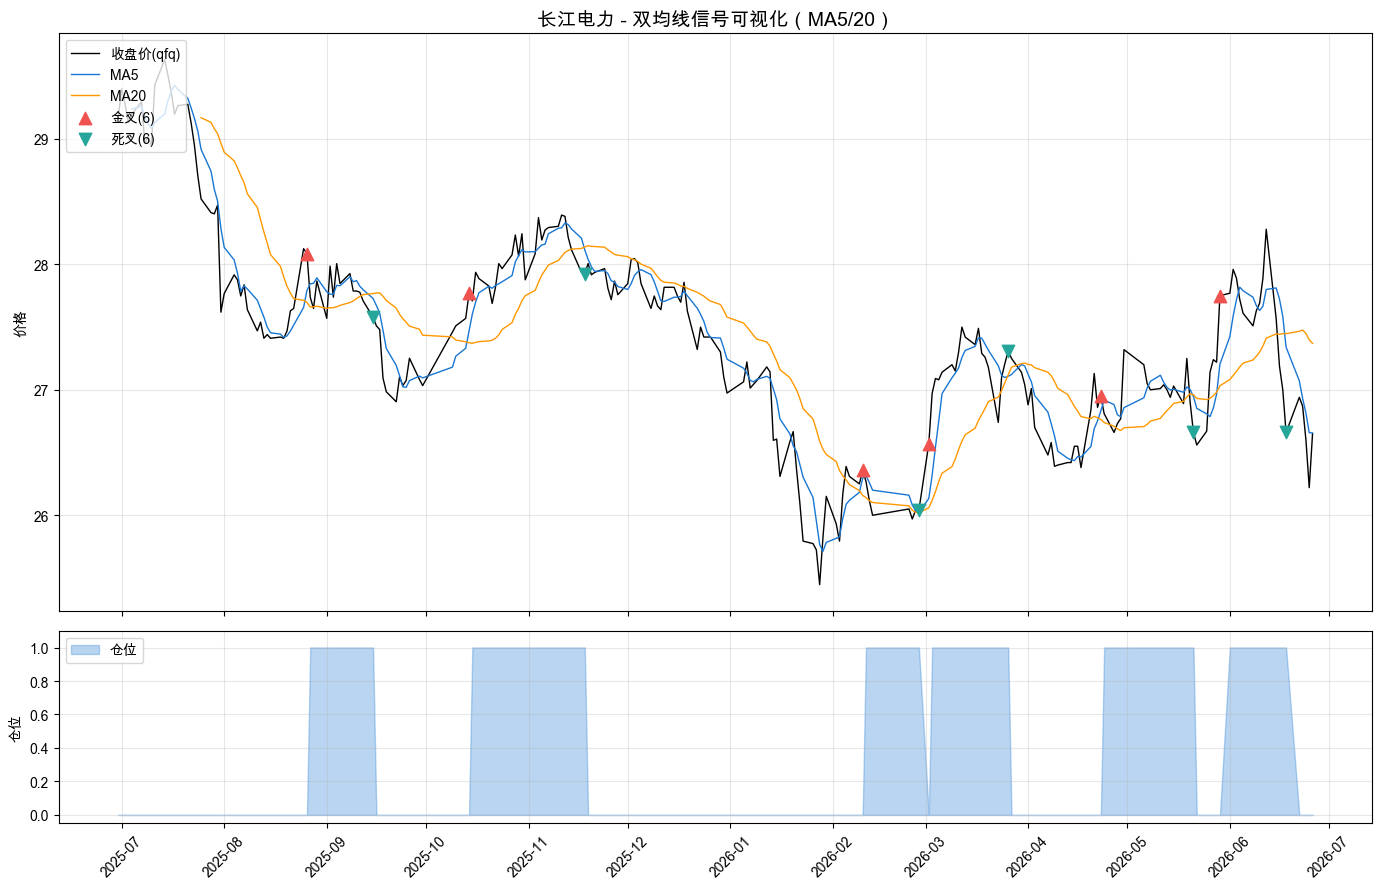

已保存: /Users/stella/Documents/LLM辅助量化交易/result/backtest_charts/长江电力/v7_ma_signals.png


In [8]:
# ── 长江电力 - 双均线交易信号可视化 ──
# 子图1：收盘价 + 快/慢均线 + 金叉死叉信号点
# 子图2：仓位变化 + 净值曲线

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

name = '长江电力'
data = STOCKS[name]
fast = MA_PARAMS['fast']; slow = MA_PARAMS['slow']
fast_ma = data['close_qfq'].rolling(fast).mean()
slow_ma = data['close_qfq'].rolling(slow).mean()

# 金叉 / 死叉（基于仓位切换，与引擎逻辑一致）
sigs = dual_ma_signal(data, MA_PARAMS).values
gold_idx, dead_idx = [], []
for t in range(1, len(sigs)):
    if sigs[t] == 1.0 and sigs[t-1] == 0.0:
        gold_idx.append(t)
    elif sigs[t] == 0.0 and sigs[t-1] == 1.0:
        dead_idx.append(t)

dates = data['trade_date']
fig, axes = plt.subplots(2, 1, figsize=(14, 9), dpi=100, sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = axes

# 子图1：价格 + 均线 + 信号
ax1.plot(dates, data['close_qfq'], label='收盘价(qfq)', color='black', linewidth=1)
ax1.plot(dates, fast_ma, label=f'MA{fast}', color='#1976d2', linewidth=1)
ax1.plot(dates, slow_ma, label=f'MA{slow}', color='#ff9800', linewidth=1)
ax1.scatter(dates.iloc[gold_idx], data['close_qfq'].iloc[gold_idx],
            marker='^', color='#ef5350', s=80, zorder=5, label=f'金叉({len(gold_idx)})')
ax1.scatter(dates.iloc[dead_idx], data['close_qfq'].iloc[dead_idx],
            marker='v', color='#26a69a', s=80, zorder=5, label=f'死叉({len(dead_idx)})')
ax1.set_title(f'{name} - 双均线信号可视化（MA{fast}/{slow}）', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 子图2：仓位 + 净值
res = results[f'{name}-双均线']
ax2.fill_between(dates, res.positions.values, 0,
                 color='#1976d2', alpha=0.3, label='仓位')
ax2.set_ylabel('仓位')
ax2.set_ylim(-0.05, 1.1)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

plt.tight_layout()
out = os.path.join(CHARTS_DIR, name, 'v7_ma_signals.png')
os.makedirs(os.path.join(CHARTS_DIR, name), exist_ok=True)
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'已保存: {out}')


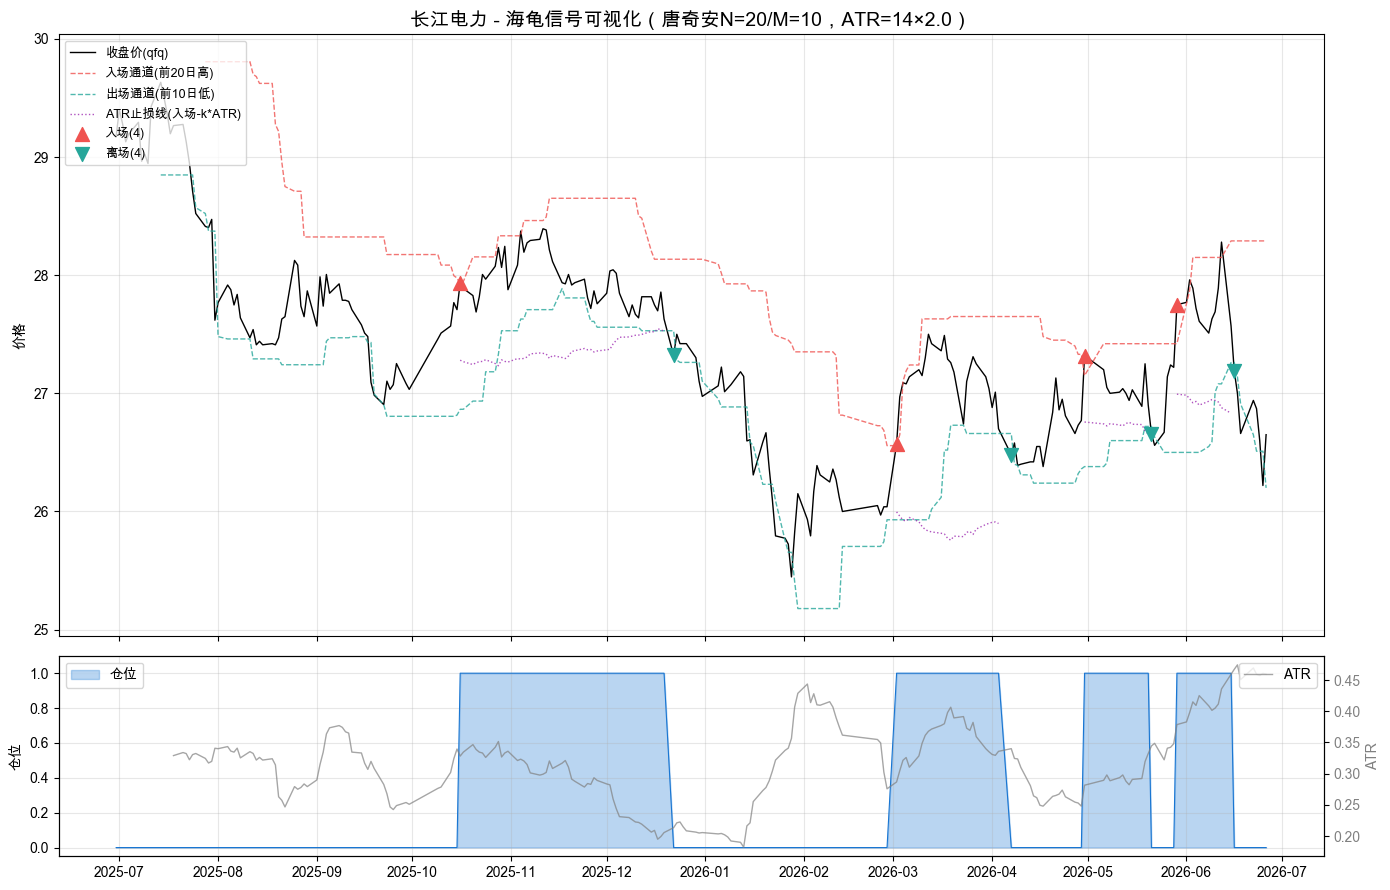

已保存: /Users/stella/Documents/LLM辅助量化交易/result/backtest_charts/长江电力/v8_turtle_signals.png


In [9]:
# ── 长江电力 - 海龟交易信号可视化 ──
# 子图1：收盘价 + 唐奇安通道（入场高/出场低） + ATR止损线
# 子图2：ATR 数值 + 仓位

name = '长江电力'
data = STOCKS[name]
p = TURTLE_PARAMS
n, m = p['entry_period'], p['exit_period']
k, atr_p = p['atr_multiplier'], p['atr_period']

c = data['close_qfq'].values
h = data['high_qfq'].values
l = data['low_qfq'].values

# 唐奇安通道（shift(1)）
entry_high = pd.Series(h).rolling(n).max().shift(1).values
exit_low = pd.Series(l).rolling(m).min().shift(1).values

# ATR
prev_c = np.concatenate([[np.nan], c[:-1]])
tr = np.maximum(np.maximum(h - l, np.abs(h - prev_c)), np.abs(l - prev_c))
atr = pd.Series(tr).rolling(atr_p).mean().values

# 逐日仓位 & 入场价
sigs = turtle_signal(data, TURTLE_PARAMS).values
entry_price_seq = np.full(len(c), np.nan)
stop_seq = np.full(len(c), np.nan)
entry_price = np.nan
for t in range(len(c)):
    if sigs[t] == 1.0:
        if np.isnan(entry_price) or (t > 0 and sigs[t-1] == 0.0):
            entry_price = c[t]
        entry_price_seq[t] = entry_price
        stop_seq[t] = entry_price - k * (atr[t] if not np.isnan(atr[t]) else 0)
    else:
        entry_price = np.nan

# 仓位变化点（入场/离场）
entry_idx, exit_idx = [], []
for t in range(1, len(sigs)):
    if sigs[t] == 1.0 and sigs[t-1] == 0.0:
        entry_idx.append(t)
    elif sigs[t] == 0.0 and sigs[t-1] == 1.0:
        exit_idx.append(t)

dates = data['trade_date']
fig, axes = plt.subplots(2, 1, figsize=(14, 9), dpi=100, sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = axes

# 子图1：价格 + 通道 + 止损 + 调仓点
ax1.plot(dates, c, label='收盘价(qfq)', color='black', linewidth=1)
ax1.plot(dates, entry_high, label=f'入场通道(前{n}日高)',
         color='#ef5350', linewidth=1, linestyle='--', alpha=0.8)
ax1.plot(dates, exit_low, label=f'出场通道(前{m}日低)',
         color='#26a69a', linewidth=1, linestyle='--', alpha=0.8)
ax1.plot(dates, stop_seq, label=f'ATR止损线(入场-k*ATR)',
         color='#9c27b0', linewidth=1, linestyle=':', alpha=0.8)
ax1.scatter(dates.iloc[entry_idx], c[entry_idx],
            marker='^', color='#ef5350', s=100, zorder=5,
            label=f'入场({len(entry_idx)})')
ax1.scatter(dates.iloc[exit_idx], c[exit_idx],
            marker='v', color='#26a69a', s=100, zorder=5,
            label=f'离场({len(exit_idx)})')
ax1.set_title(
    f'{name} - 海龟信号可视化（唐奇安N={n}/M={m}，ATR={atr_p}×{k}）',
    fontsize=14, fontweight='bold')
ax1.set_ylabel('价格')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 子图2：ATR + 仓位
ax2.fill_between(dates, sigs, 0,
                 color='#1976d2', alpha=0.3, label='仓位')
ax2.plot(dates, sigs, color='#1976d2', linewidth=0.8)
ax2.set_ylabel('仓位')
ax2.set_ylim(-0.05, 1.1)
ax2_twin = ax2.twinx()
ax2_twin.plot(dates, atr, color='gray', linewidth=1, alpha=0.7, label='ATR')
ax2_twin.set_ylabel('ATR', color='gray')
ax2_twin.tick_params(axis='y', labelcolor='gray')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

plt.tight_layout()
out = os.path.join(CHARTS_DIR, name, 'v8_turtle_signals.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'已保存: {out}')


## 9. 长江电力 - 参数敏感性分析



参数敏感性分析完成：共 53 组有效参数组合
 fast  slow     累计收益率     年化收益率    Sharpe      最大回撤  交易次数
    3    15 -0.097427 -0.101640 -1.529116 -0.097427    10
    3    20 -0.046497 -0.048567 -0.873696 -0.049415     8
    3    30 -0.066650 -0.069584 -1.316064 -0.078183     6
    3    40 -0.080725 -0.084250 -1.499678 -0.092960     6
    3    50 -0.102470 -0.106888 -1.828223 -0.114416     6
    3    60 -0.078135 -0.081552 -1.375920 -0.085528     6
    3    80 -0.074771 -0.078047 -1.343129 -0.074771     5
    3   100 -0.086351 -0.090109 -1.966713 -0.091904     6
    5    15 -0.104483 -0.108982 -1.659720 -0.104483     8
    5    20 -0.063764 -0.066575 -1.130144 -0.064161     6
    5    30 -0.068885 -0.071913 -1.320533 -0.089639     6
    5    40 -0.051659 -0.053952 -1.112176 -0.076353     4
    5    50 -0.059733 -0.062373 -1.174914 -0.084218     5
    5    60 -0.073950 -0.077192 -1.310643 -0.087284     4
    5    80 -0.046670 -0.048747 -0.945519 -0.058261     3
    5   100 -0.067964 -0.070954 -1.462927 -0.067

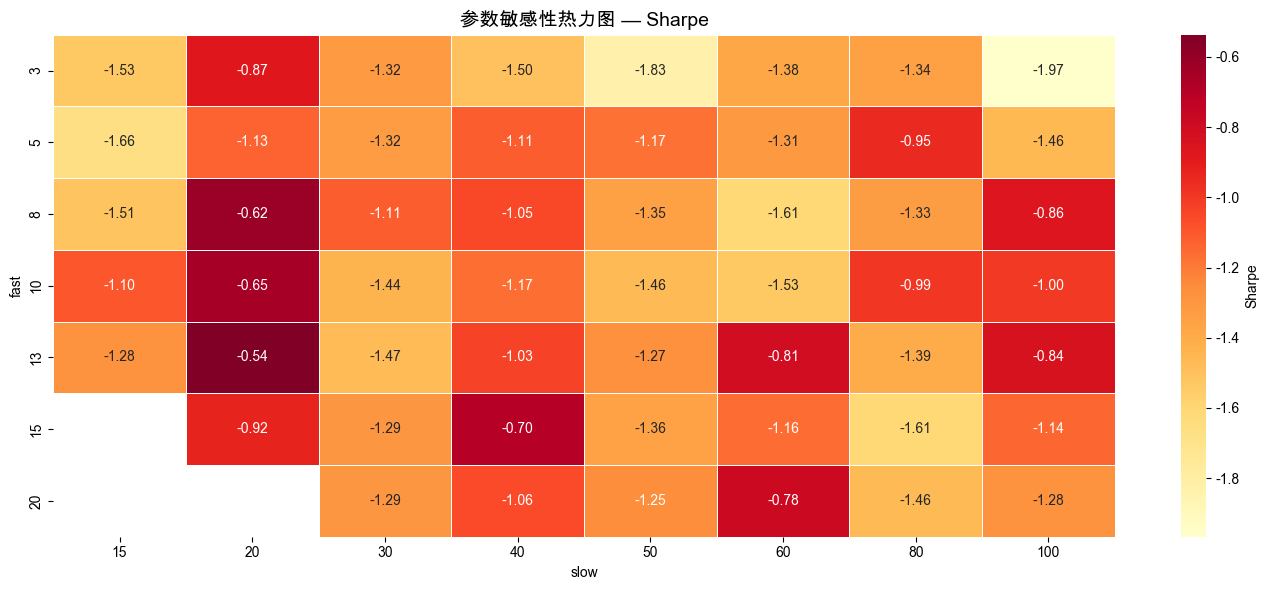

无有效数据，跳过热力图绘制


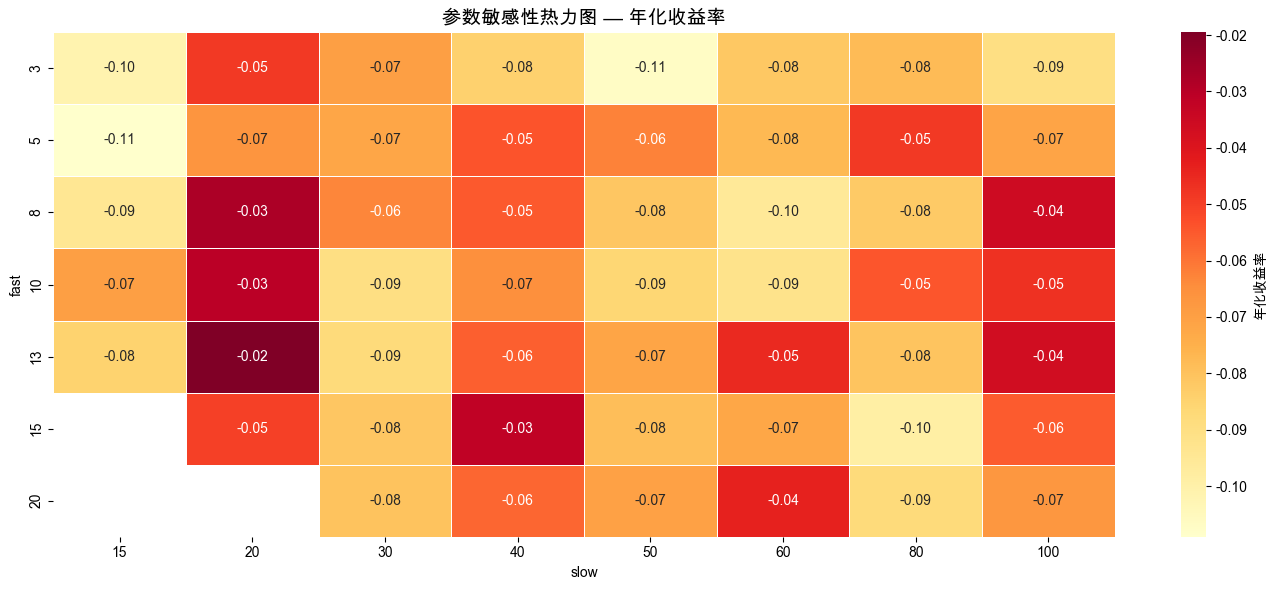

无有效数据，跳过热力图绘制
敏感性热力图已保存


In [10]:
# ── 长江电力 - 参数敏感性分析 ──
# 对双均线（fast/slow）和海龟（entry_period/exit_period）做网格搜索

# 1) 双均线：(fast, slow) 网格
ma_grid = {
    'fast': [3, 5, 8, 10, 13, 15, 20],
    'slow': [15, 20, 30, 40, 50, 60, 80, 100],
}
ma_sens = Evaluator.sensitivity_analysis(
    engine=engine,
    data=STOCKS['长江电力'],
    signal_fn=dual_ma_signal,
    param_grid=ma_grid,
    constraint=lambda p: p['fast'] < p['slow'],
)

# 2) 海龟：(entry_period, exit_period) 网格
turtle_grid = {
    'entry_period': [10, 15, 20, 25, 30, 40],
    'exit_period':  [5, 10, 15, 20, 25],
}
turtle_sens = Evaluator.sensitivity_analysis(
    engine=engine,
    data=STOCKS['长江电力'],
    signal_fn=turtle_signal,
    param_grid=turtle_grid,
    constraint=lambda p: p['entry_period'] > p['exit_period'],
)

# 热力图：分别画 Sharpe 与 年化收益率
os.makedirs(os.path.join(CHARTS_DIR, '长江电力'), exist_ok=True)
for metric in ['Sharpe', '年化收益率']:
    Visualizer.plot_sensitivity_heatmap(
        ma_sens, metric=metric,
        save_path=os.path.join(CHARTS_DIR, '长江电力', f'v9_ma_sens_{metric}.png'))
    Visualizer.plot_sensitivity_heatmap(
        turtle_sens, metric=metric,
        save_path=os.path.join(CHARTS_DIR, '长江电力', f'v10_turtle_sens_{metric}.png'))

print('敏感性热力图已保存')
